# **Exercise 6: Predicting Fuel Poverty Status**

## Overview

In this notebook, we explore the **English Housing Survey (EHS)** [1] dataset and apply classification methods to predict whether a household is in fuel poverty.
Next, we develop an optimization-based approach to generate counterfactual explanations, which represent the smallest change in the feature vector that alters the classifier's output. 
In this example, the counterfactual explanation can be interpreted as the minimal change required to lift a household out of energy poverty.

References
1. Ministry of Housing, Communities and Local Government. (2024). English Housing Survey. [data series]. 7th Release. UK Data Service. SN: 200010, DOI: http://doi.org/10.5255/UKDA-Series-200010

## Set up

Load the required Python libraries and the dataset. Update the `data_path` variable to point to the folder containing `FuelPoverty_2019.csv`.

In [12]:
# Load libraries
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Plot settings
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.dpi'] = 600
plt.rcParams['font.size'] = 8
plt.rcParams['figure.figsize'] = (8, 3.5)


def mcfadden_r2(y_true: np.ndarray, p_hat: np.ndarray) -> float:
    """McFadden pseudo-R^2 for binary classifiers using predicted probabilities."""
    eps = 1e-15
    y = y_true.astype(float)
    p = np.clip(p_hat.astype(float), eps, 1 - eps)

    ll_model = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
    p0 = np.clip(np.mean(y), eps, 1 - eps)
    ll_null = np.sum(y * np.log(p0) + (1 - y) * np.log(1 - p0))
    return 1.0 - (ll_model / ll_null)


def evaluate_binary_classifier(y_true, proba, threshold=0.5, title_prefix="", plot_roc=True):
    """Evaluate a binary classifier from predicted probabilities."""
    y_pred = (proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, proba)
    r2 = mcfadden_r2(np.asarray(y_true), np.asarray(proba))

    print("\n" + "=" * 60)
    if title_prefix:
        print(title_prefix)
    print("Confusion matrix (rows=true [0,1], cols=pred [0,1]):\n", cm)
    print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  AUC={auc:.3f}")
    print(f"McFadden pseudo-R²={r2:.3f}")

    if plot_roc:
        fpr, tpr, _ = roc_curve(y_true, proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC curve{(' - ' + title_prefix) if title_prefix else ''}")
        plt.legend()
        plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "mcfadden_r2": r2,
    }

def aggregate_importances(feature_names, importances, original_features):
    """Aggregate one-hot encoded importances back to original feature groups."""
    aggregated = {feat: 0.0 for feat in original_features}
    for name, value in zip(feature_names, importances):
        matched = False
        for feat in original_features:
            if feat in name:
                aggregated[feat] += value
                matched = True
                break
        if not matched:
            aggregated[name] = aggregated.get(name, 0.0) + value
    return pd.Series(aggregated).sort_values(ascending=True)


data_path = r'C:\Users\ucbva19\Git projects\BENV0092\data raw'
csv_path = f"{data_path}\\FuelPoverty_2019.csv"
random_state = 42

# Load data
df = pd.read_csv(csv_path)

## Data cleaning and recoding

The dataset contains socio-economic and dwelling-level variables. We rename selected columns for readability and recode a few categorical variables.


In [13]:
# Rename selected columns
rename_map = {
    "fpLILEEflg": "In_fuel_Poverty",
    "fpfullinc": "hh_income",
    "fuelexpn": "fuel_costs",
    "Unoc": "Under_occupied",
    "gorehs": "Region",
    "tenure4x": "Tenure",
    "emphrp3x": "Head_Working_Status",
    "ethhrp2x": "Head_Ethnic_Origin",
    "Ageyng": "Age_of_youngest",
    "Ageold": "Age_of_oldest",
}
df = df.rename(columns=rename_map)

# Ensure binary target
df["In_fuel_Poverty"] = pd.to_numeric(df["In_fuel_Poverty"], errors="coerce").astype("Int64")

# Mapping dictionaries
region_map = {
    1: "North East",
    2: "North West",
    4: "Yorkshire and the Humber",
    5: "East Midlands",
    6: "West Midlands",
    7: "East",
    8: "London",
    9: "South East",
    10: "South West",
}
tenure_map = {
    1: "owner occupied",
    2: "private rented",
    3: "local authority",
    4: "housing association",
}
dwtype_map = {
    1: "end terrace",
    2: "mid terrace",
    3: "semi detached",
    4: "detached",
    5: "purpose built",
    6: "converted and non residential",
}
work_map = {1: "working", 2: "unemployed", 3: "inactive"}
eth_map = {1: "white", 2: "ethnic minority"}
epc_map = {1: "A/B/C", 2: "D", 3: "E", 4: "F", 5: "G"}
hhcomp_map = {
    1: "couple, no child(ren) under 60",
    2: "couple, no child(ren) 60 or over",
    3: "couple with child(ren)",
    4: "lone parent with child(ren)",
    5: "other multi-person households",
    6: "one person under 60",
    7: "one person aged 60 or over",
}
dfvuln_map = {1: "Vulnerable", 0: "Not vulnerable"}

for col, mp in [
    ("Region", region_map),
    ("Tenure", tenure_map),
    ("DWtype", dwtype_map),
    ("Head_Working_Status", work_map),
    ("Head_Ethnic_Origin", eth_map),
    ("EPC", epc_map),
    ("hhcompx", hhcomp_map),
    ("dfvuln", dfvuln_map),
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].map(mp)

# Remove non-residential dwellings if present
if "DWtype" in df.columns:
    df = df.loc[df["DWtype"] != "converted and non residential"].copy()

# Keep rows with non-missing target only
df = df.dropna(subset=["In_fuel_Poverty"]).copy()
df["In_fuel_Poverty"] = df["In_fuel_Poverty"].astype(int)

print(df.shape)
display(df.head())


(11520, 49)


,serialanon,In_fuel_Poverty,AHCIncomeEQ_LILEE,hh_income,fuel_costs,FuelCosteqFactor,EqAHCincDeciles_LILEE,elecmop,gasmop,aagph1819,...,FPGAP_LILEE,HousingCosts,fpbasinc,wathcost,spahcost,litecost,cookcost,fpflgb,fpflgf,FullincDeciles
0,18190000045,0,17387.00000,17387,1140.19,1.00,4,2,2,2957,...,0.000000,0.0,18687,118.69,544.79,431.99,44.72,0,0,3
1,18190000061,0,42816.00000,57216,1635.19,1.00,9,1,1,2701,...,0.000000,14400.0,59401,114.30,812.53,666.80,41.56,0,0,9
2,18190000161,0,51848.33333,78418,1808.14,1.07,10,1,88,1327,...,0.000000,16200.0,80036,263.34,846.29,630.36,68.15,0,0,10
3,18190000165,1,10536.00000,10536,1439.17,1.00,2,3,3,5350,...,264.295719,0.0,11411,59.19,748.54,589.00,42.44,1,1,1
5,18190000199,0,100000.00000,100000,2668.60,1.00,10,1,88,4530,...,0.000000,0.0,100000,318.91,1577.50,715.23,56.96,0,0,10


## Preliminary analysis

As in the in-class example, it is useful to inspect the target variable and a few key explanatory variables before fitting models.


In_fuel_Poverty
0    9772
1    1748
Name: count, dtype: int64
Fuel poverty share: 0.1517361111111111


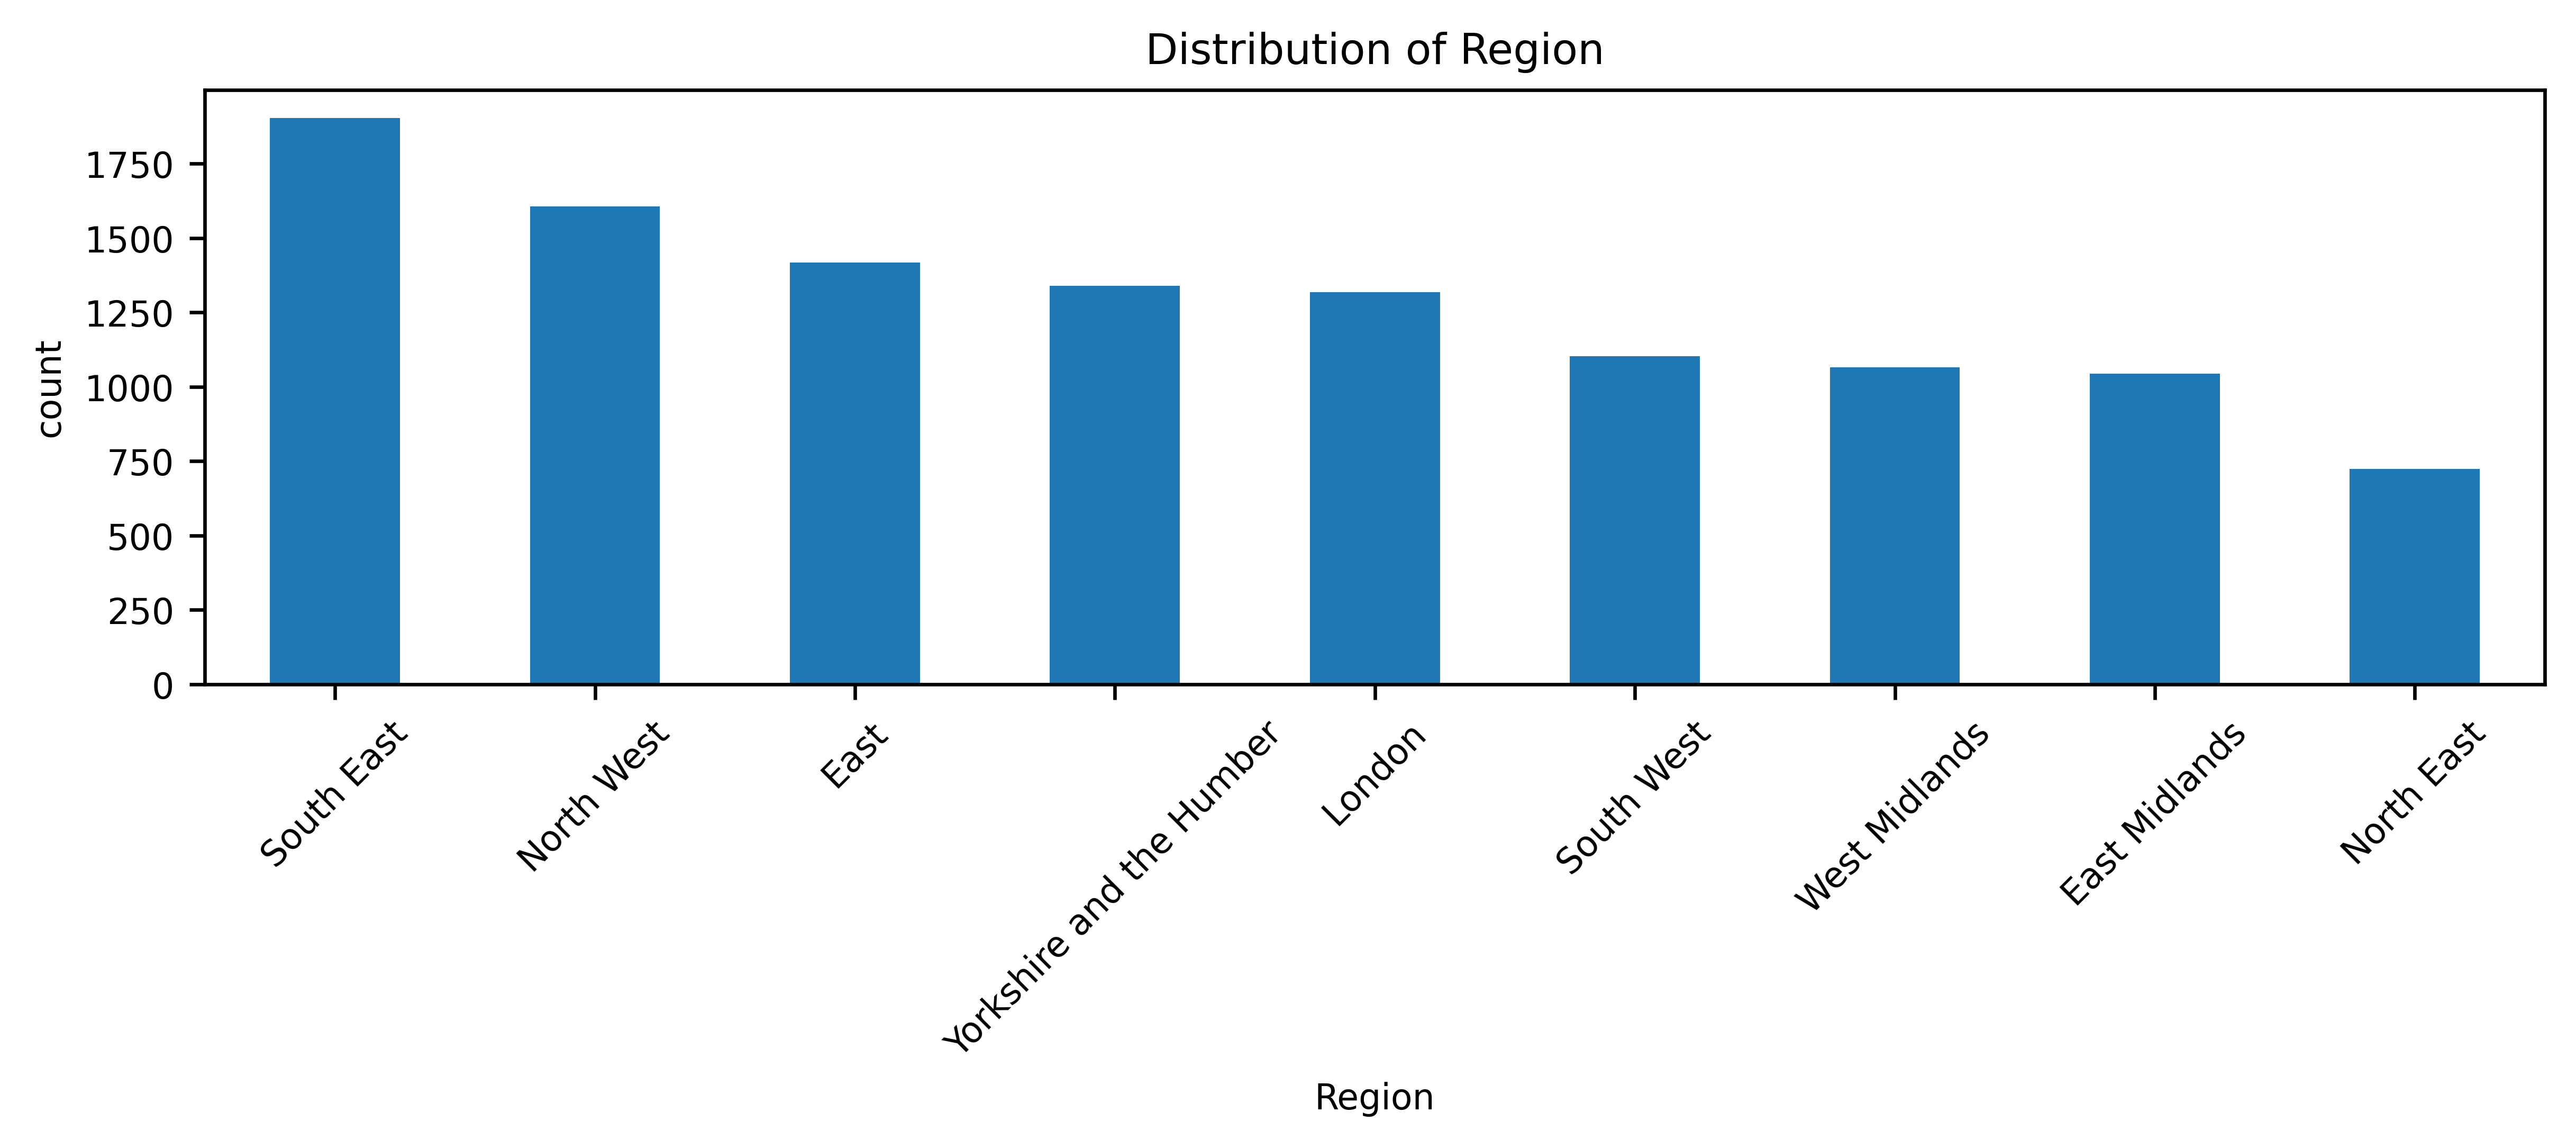

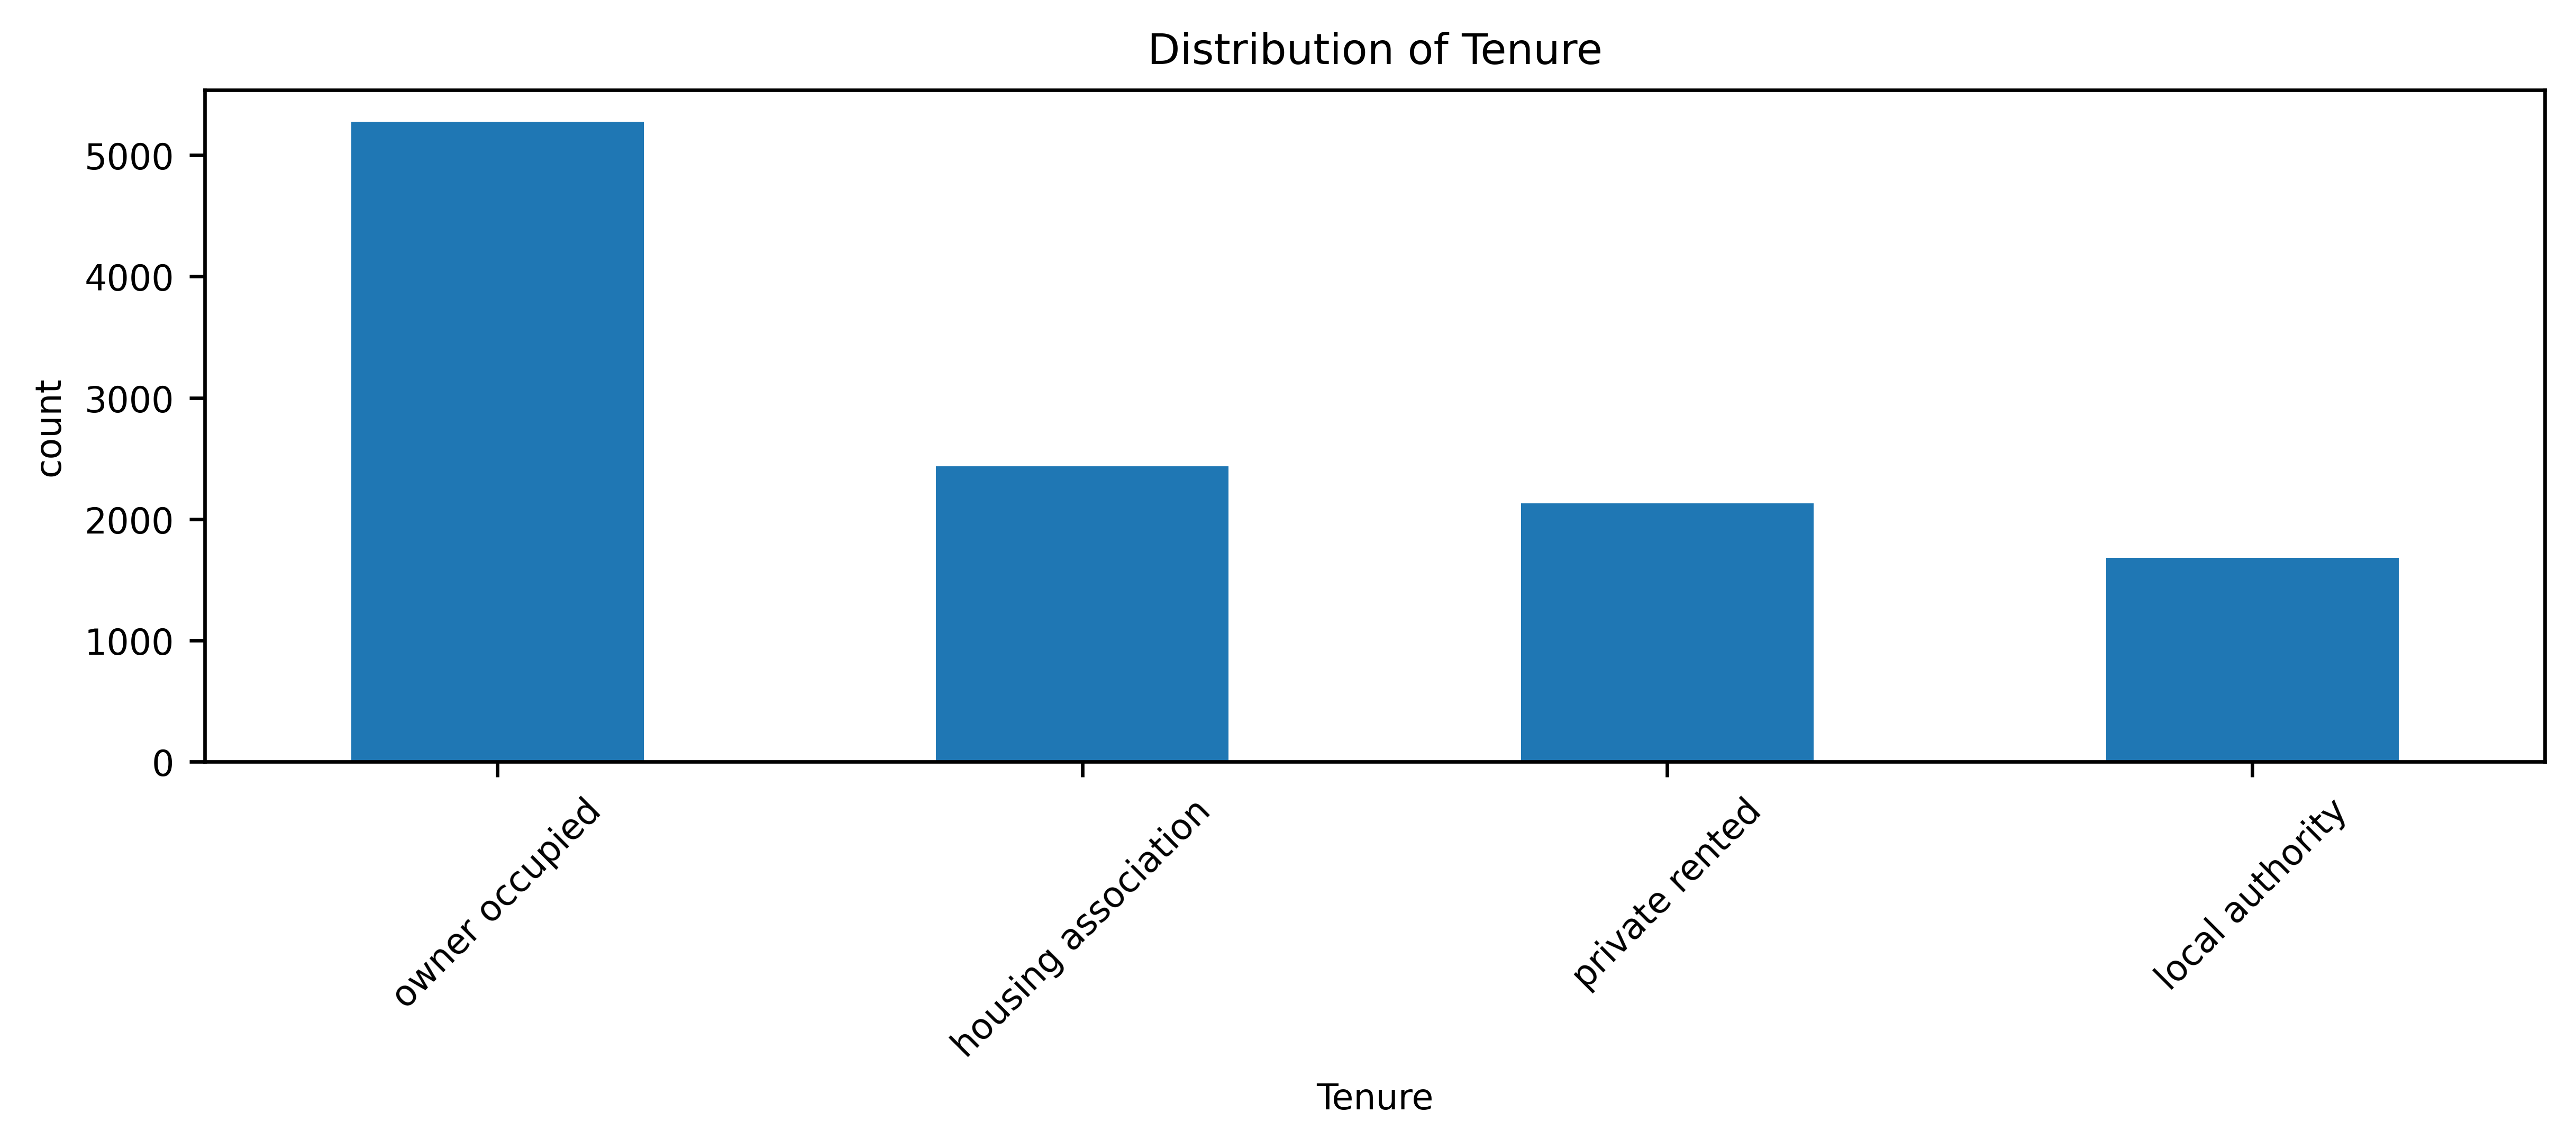

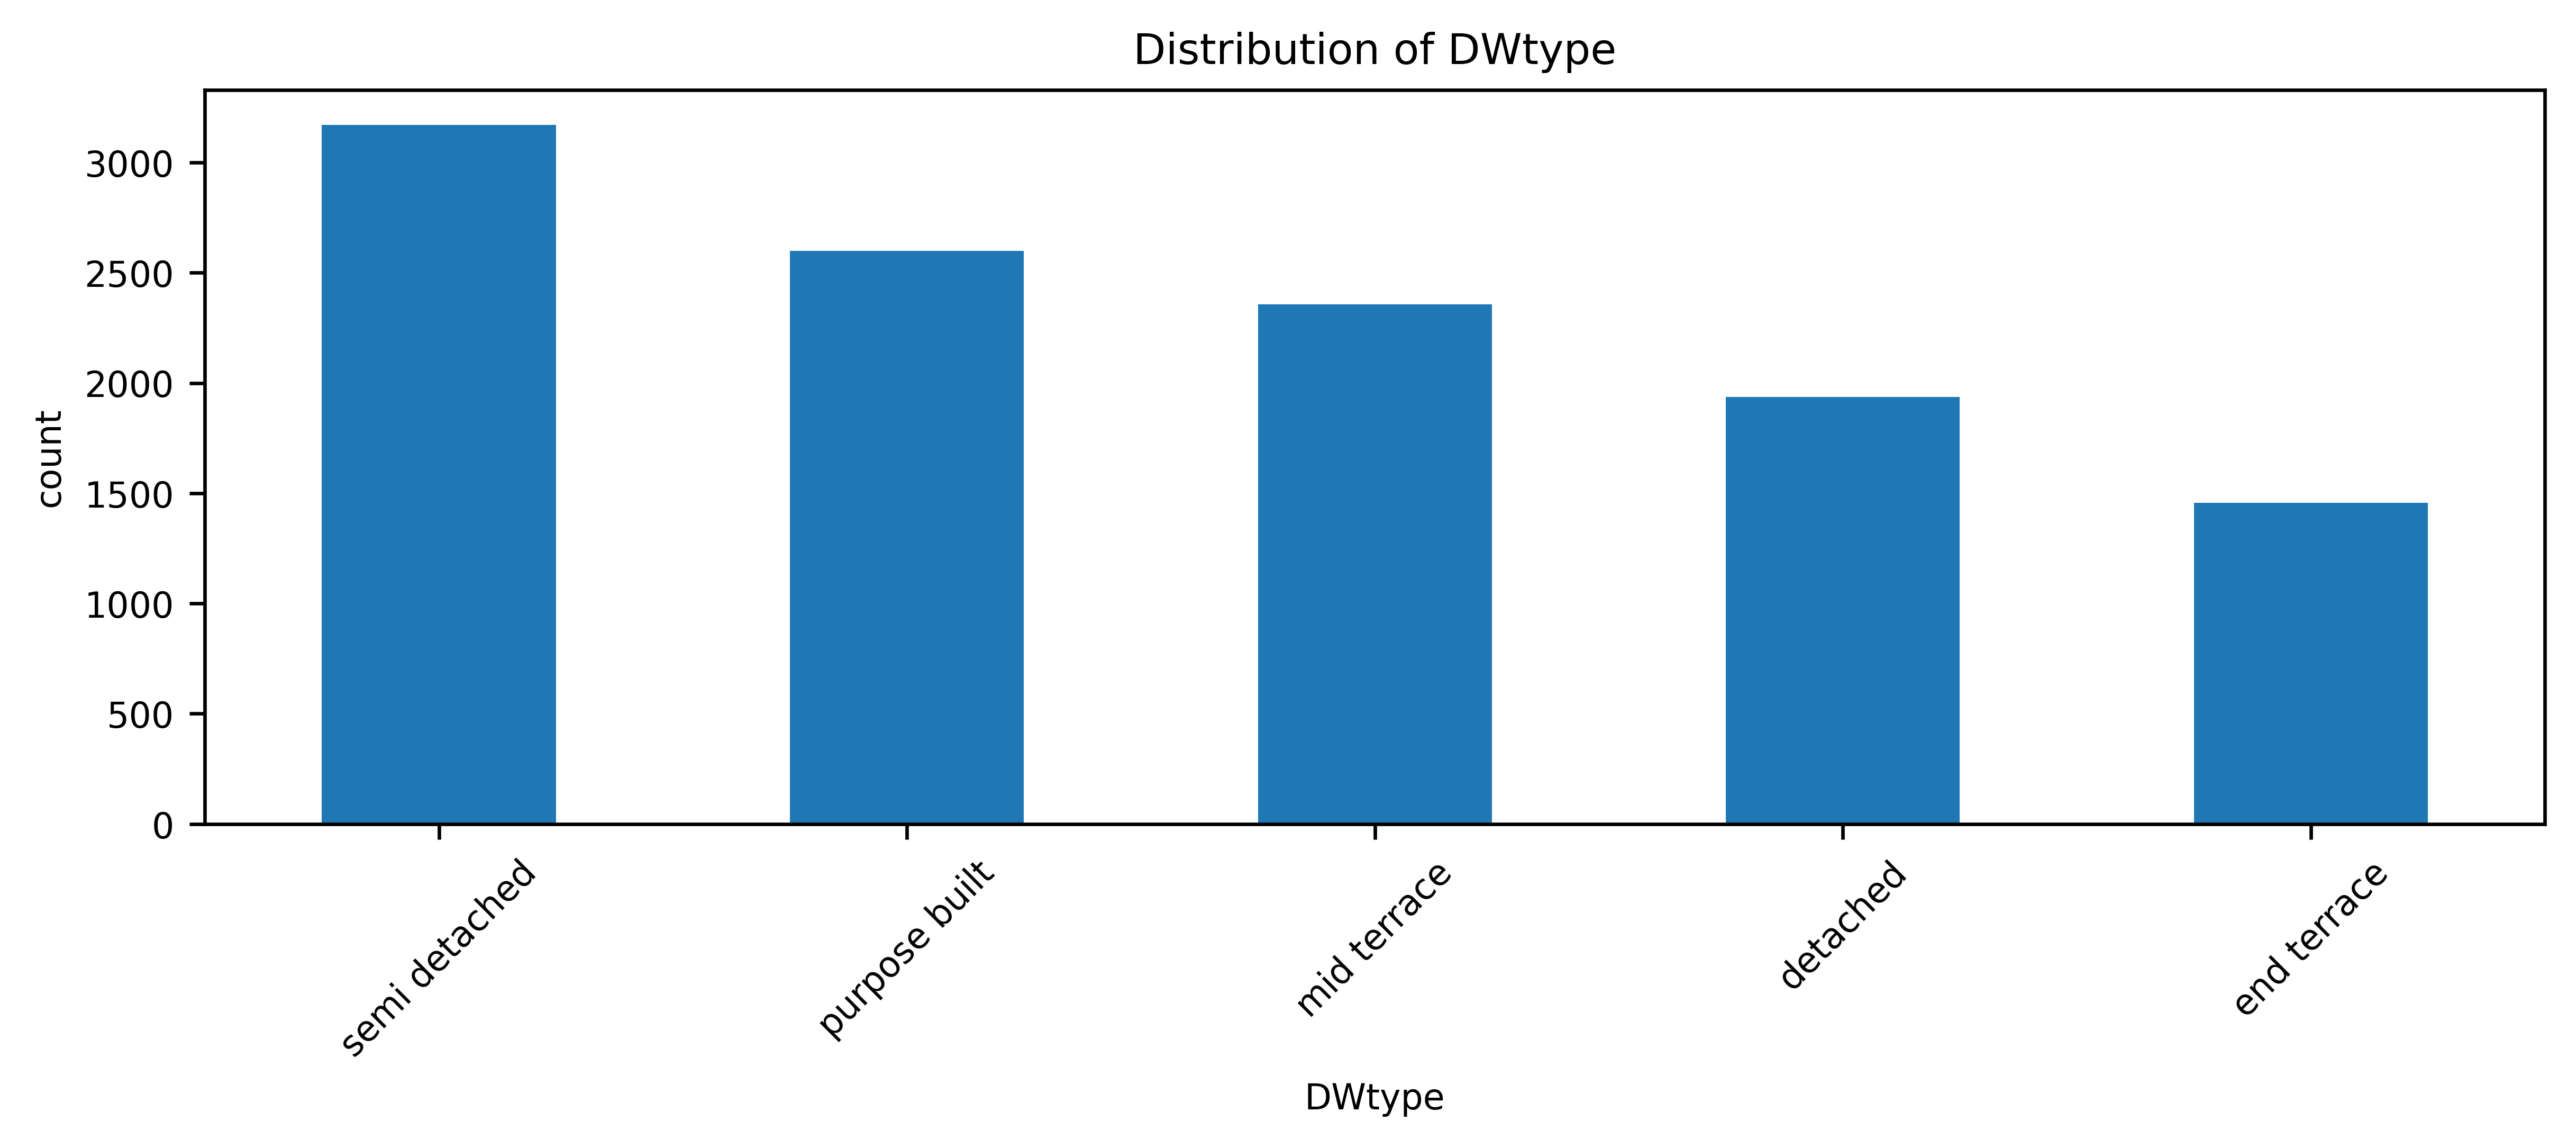

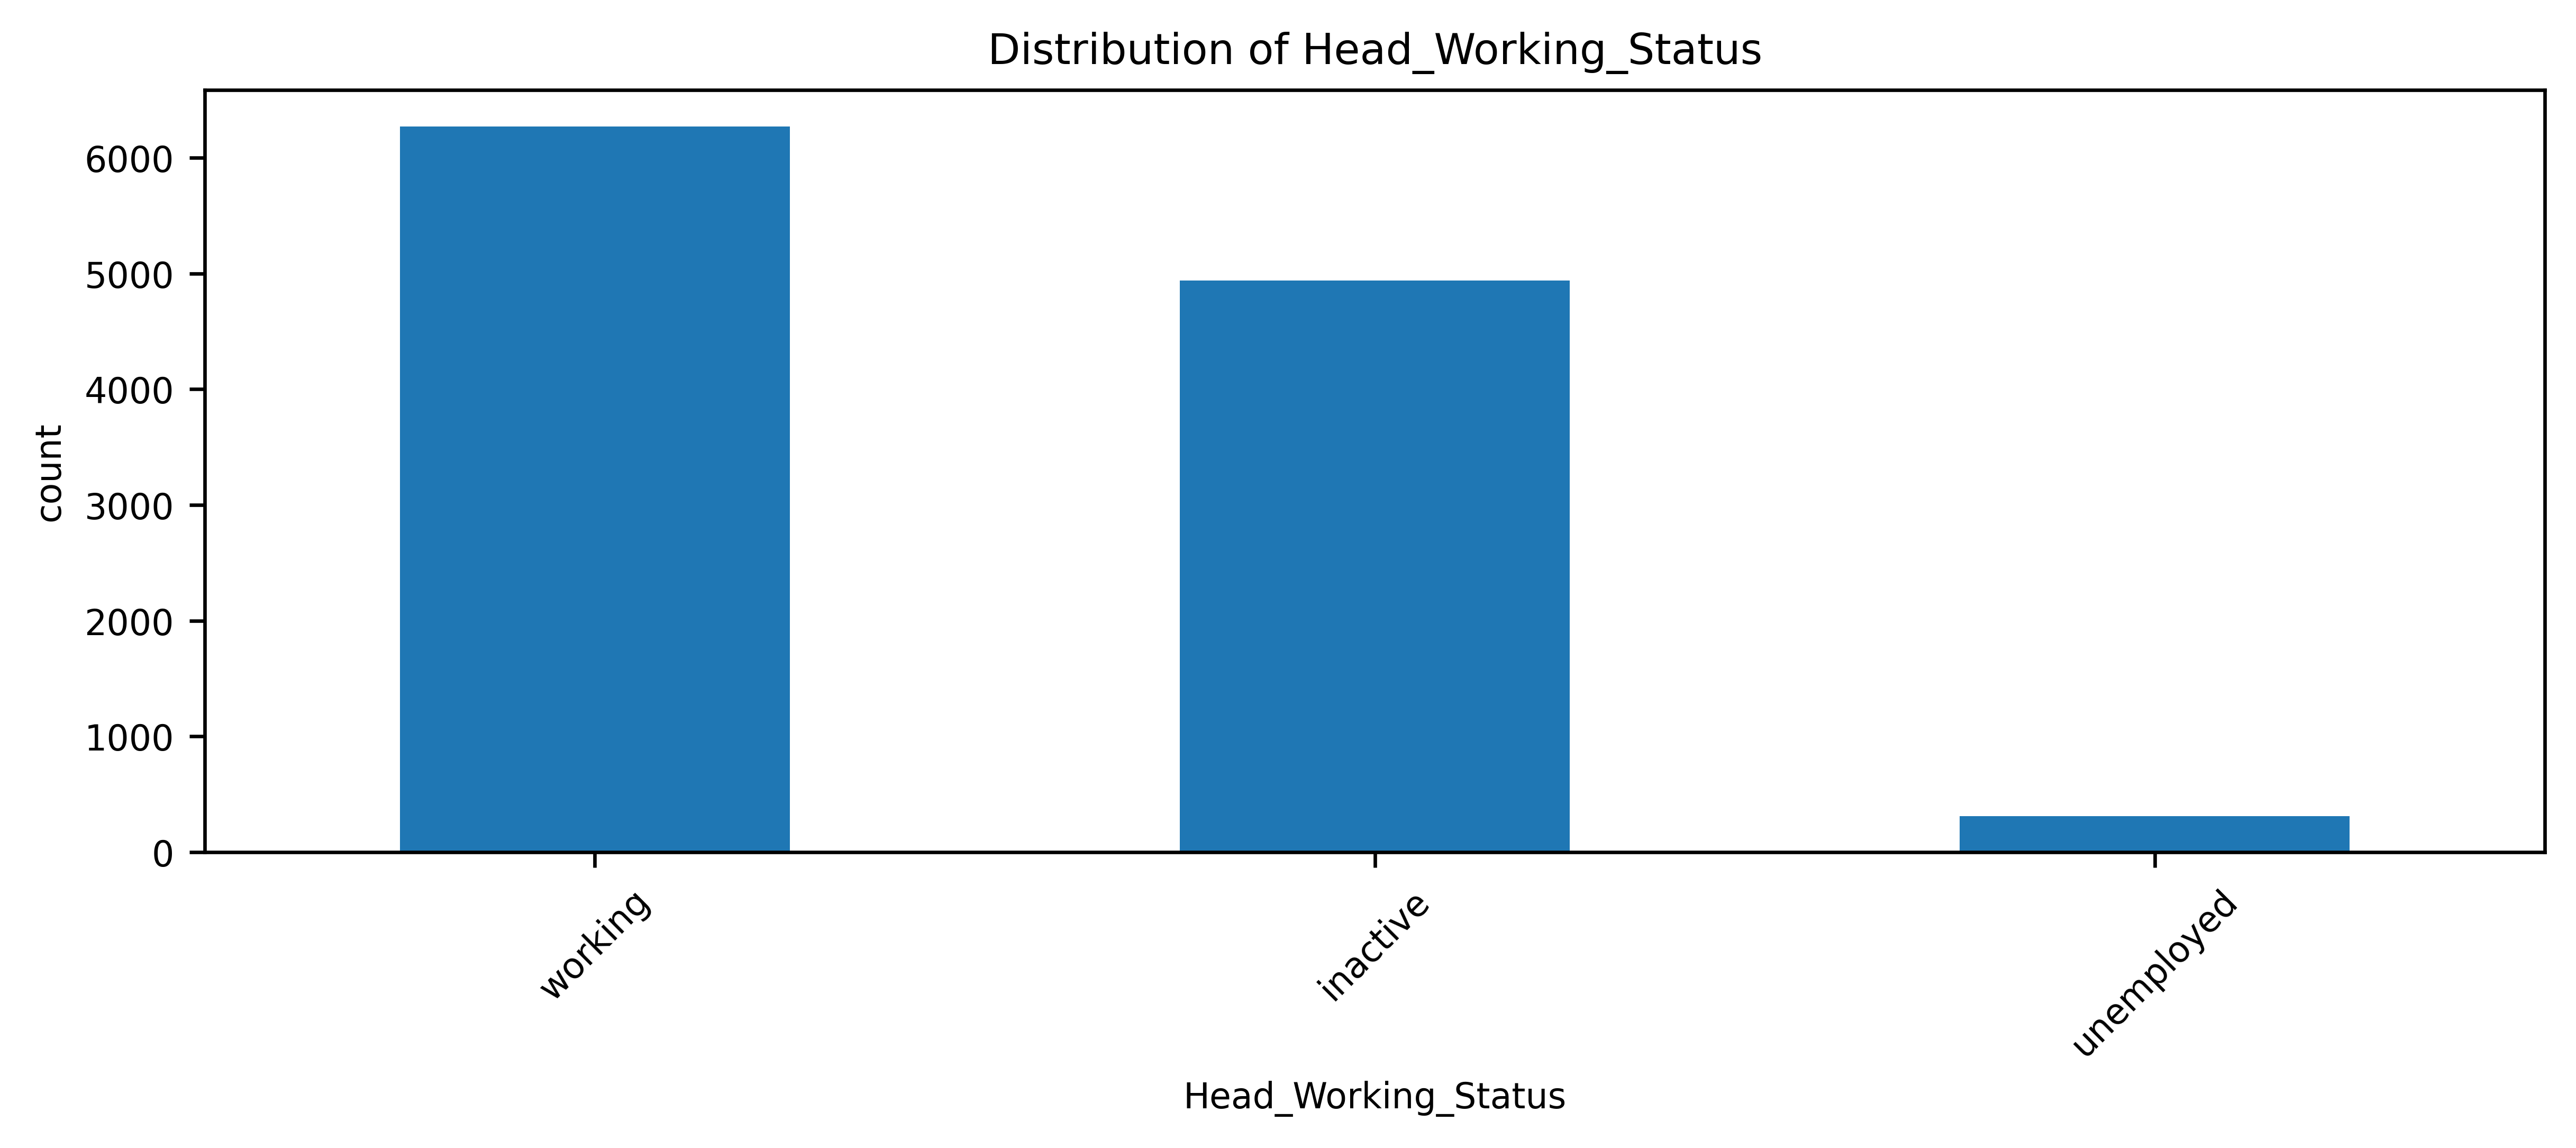

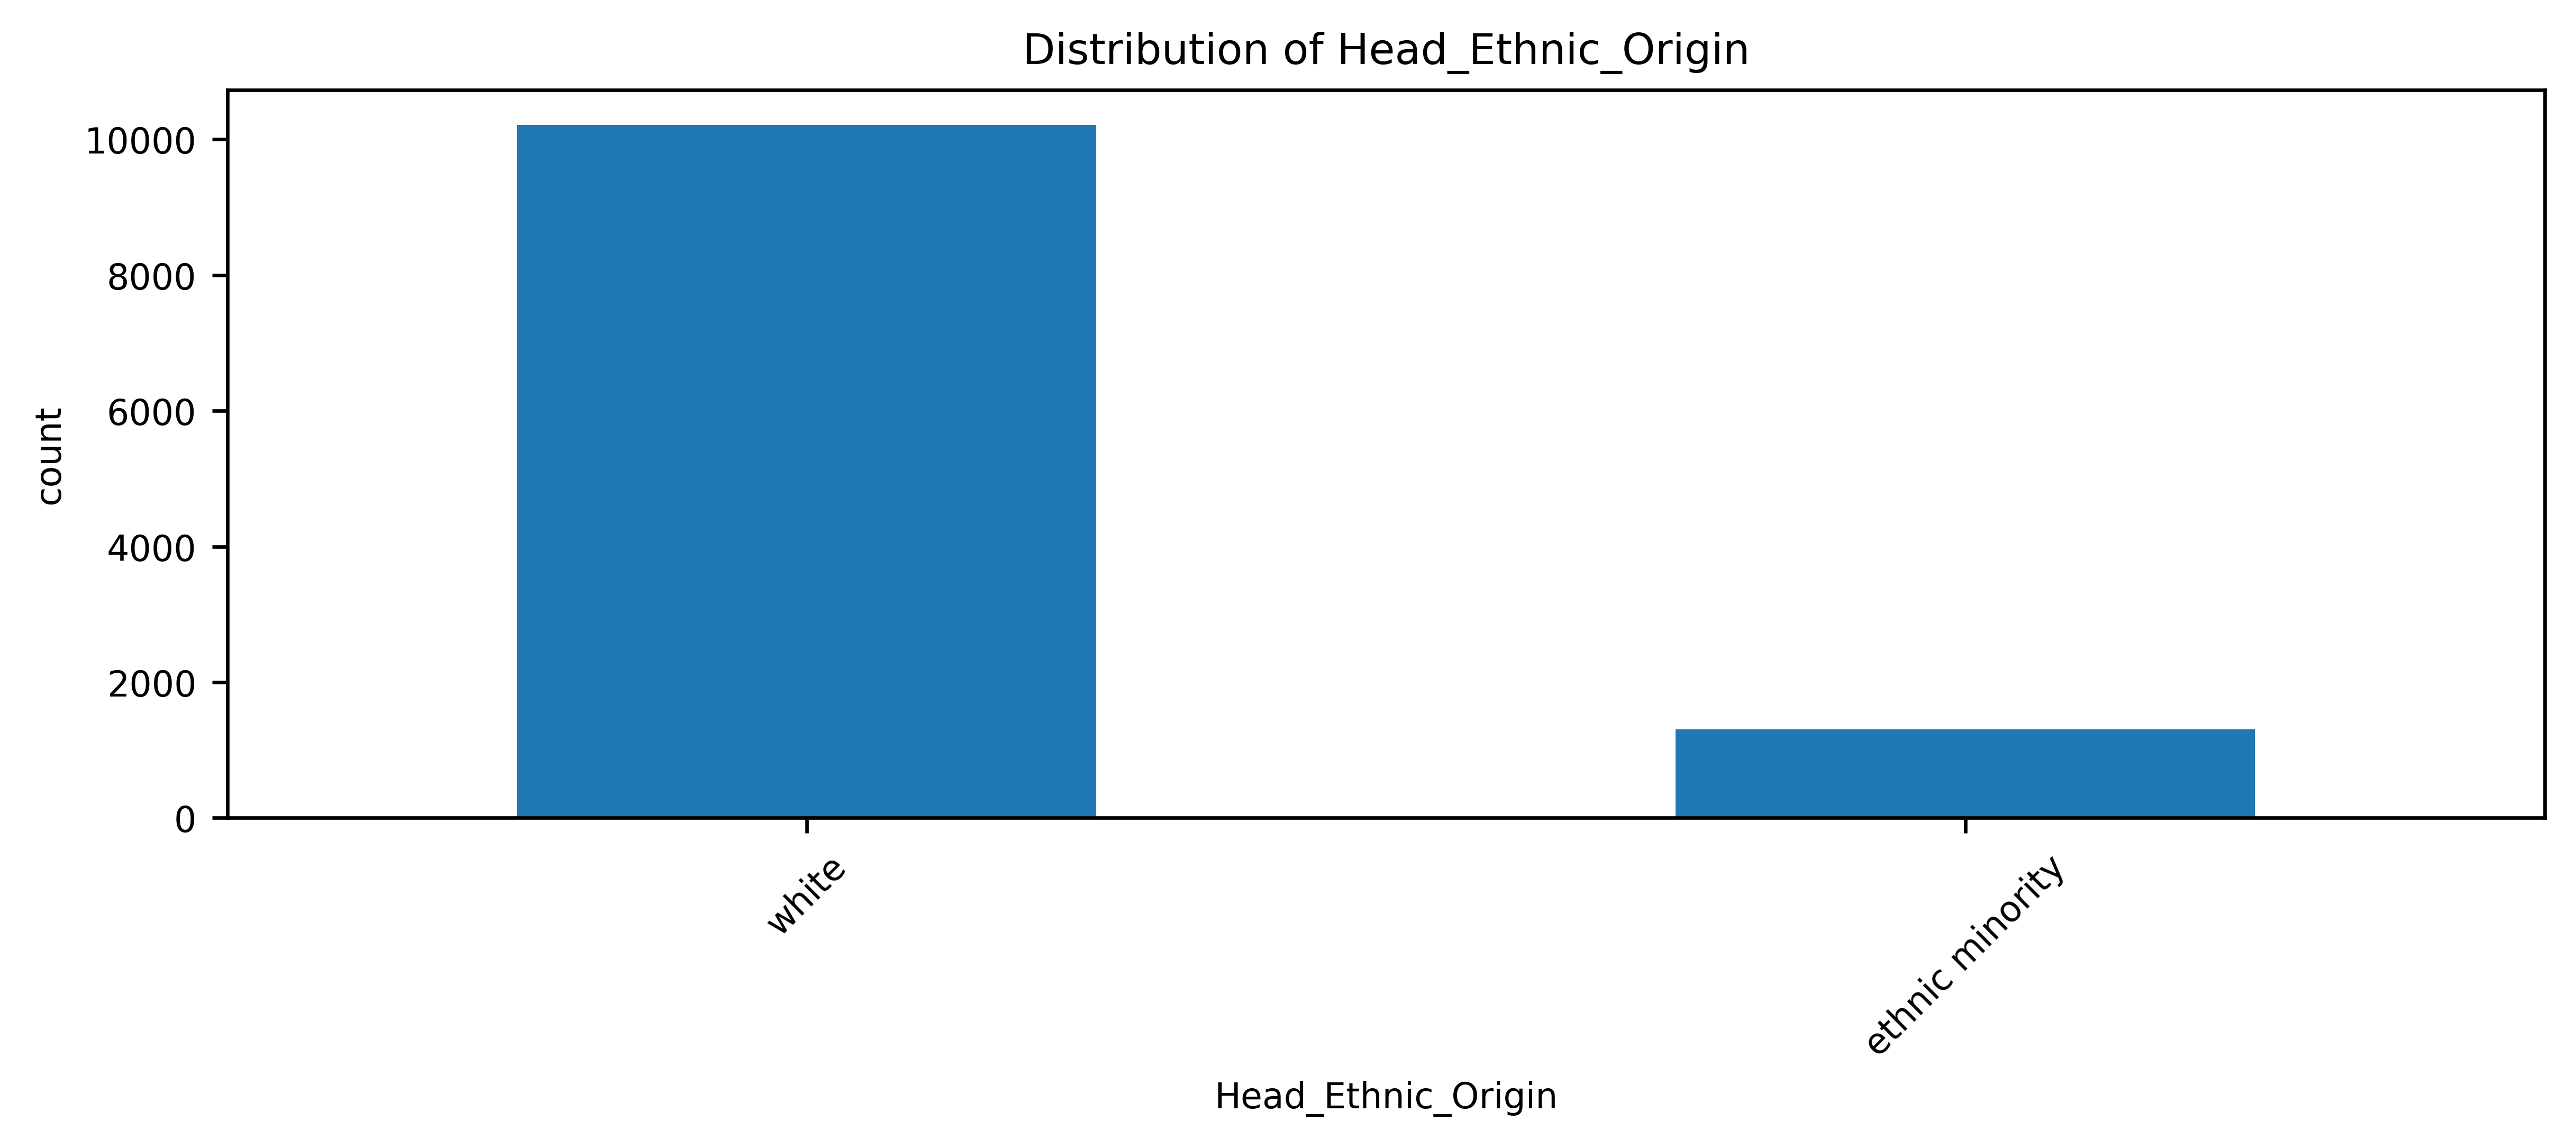

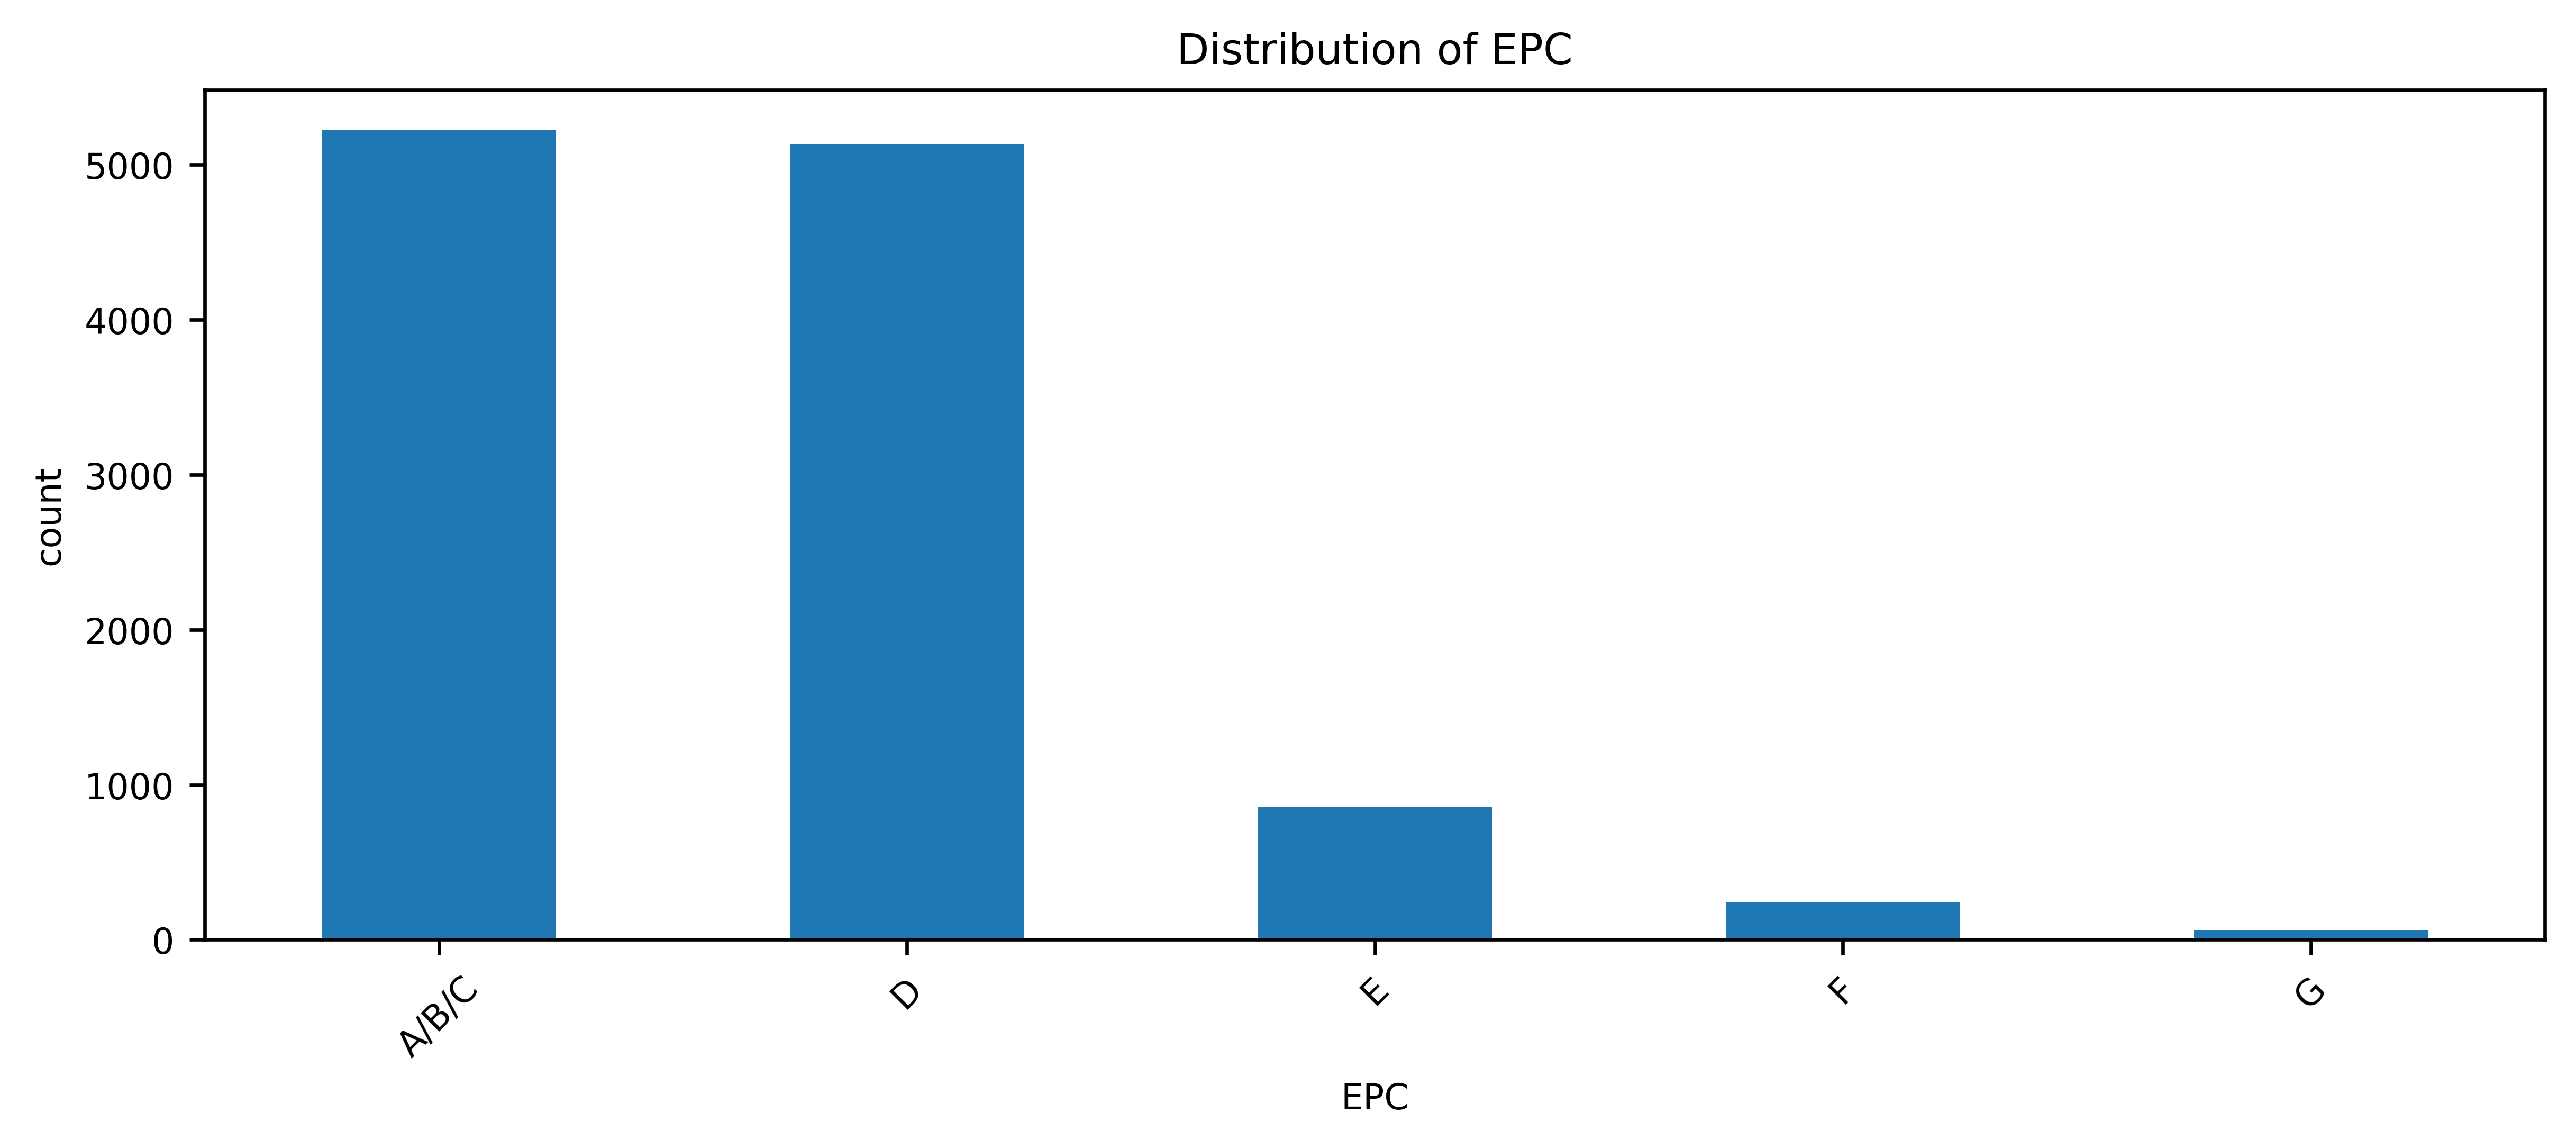

Summary statistics for hh_income
count     11520.000000
mean      30897.063108
std       19561.340814
min       -2821.000000
25%       17065.750000
50%       25728.000000
75%       39096.500000
max      100000.000000
Name: hh_income, dtype: float64
Summary statistics for fuel_costs
count    11520.000000
mean      1258.700092
std        469.925721
min        355.340000
25%        949.510000
50%       1180.035000
75%       1457.142500
max       6481.840000
Name: fuel_costs, dtype: float64
Summary statistics for Under_occupied
count    11520.000000
mean         0.258420
std          0.437785
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Under_occupied, dtype: float64
Summary statistics for Age_of_youngest
count    11520.000000
mean         4.397222
std          1.899285
min          1.000000
25%          3.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: Age_of_youngest, dtype: float64
Summ

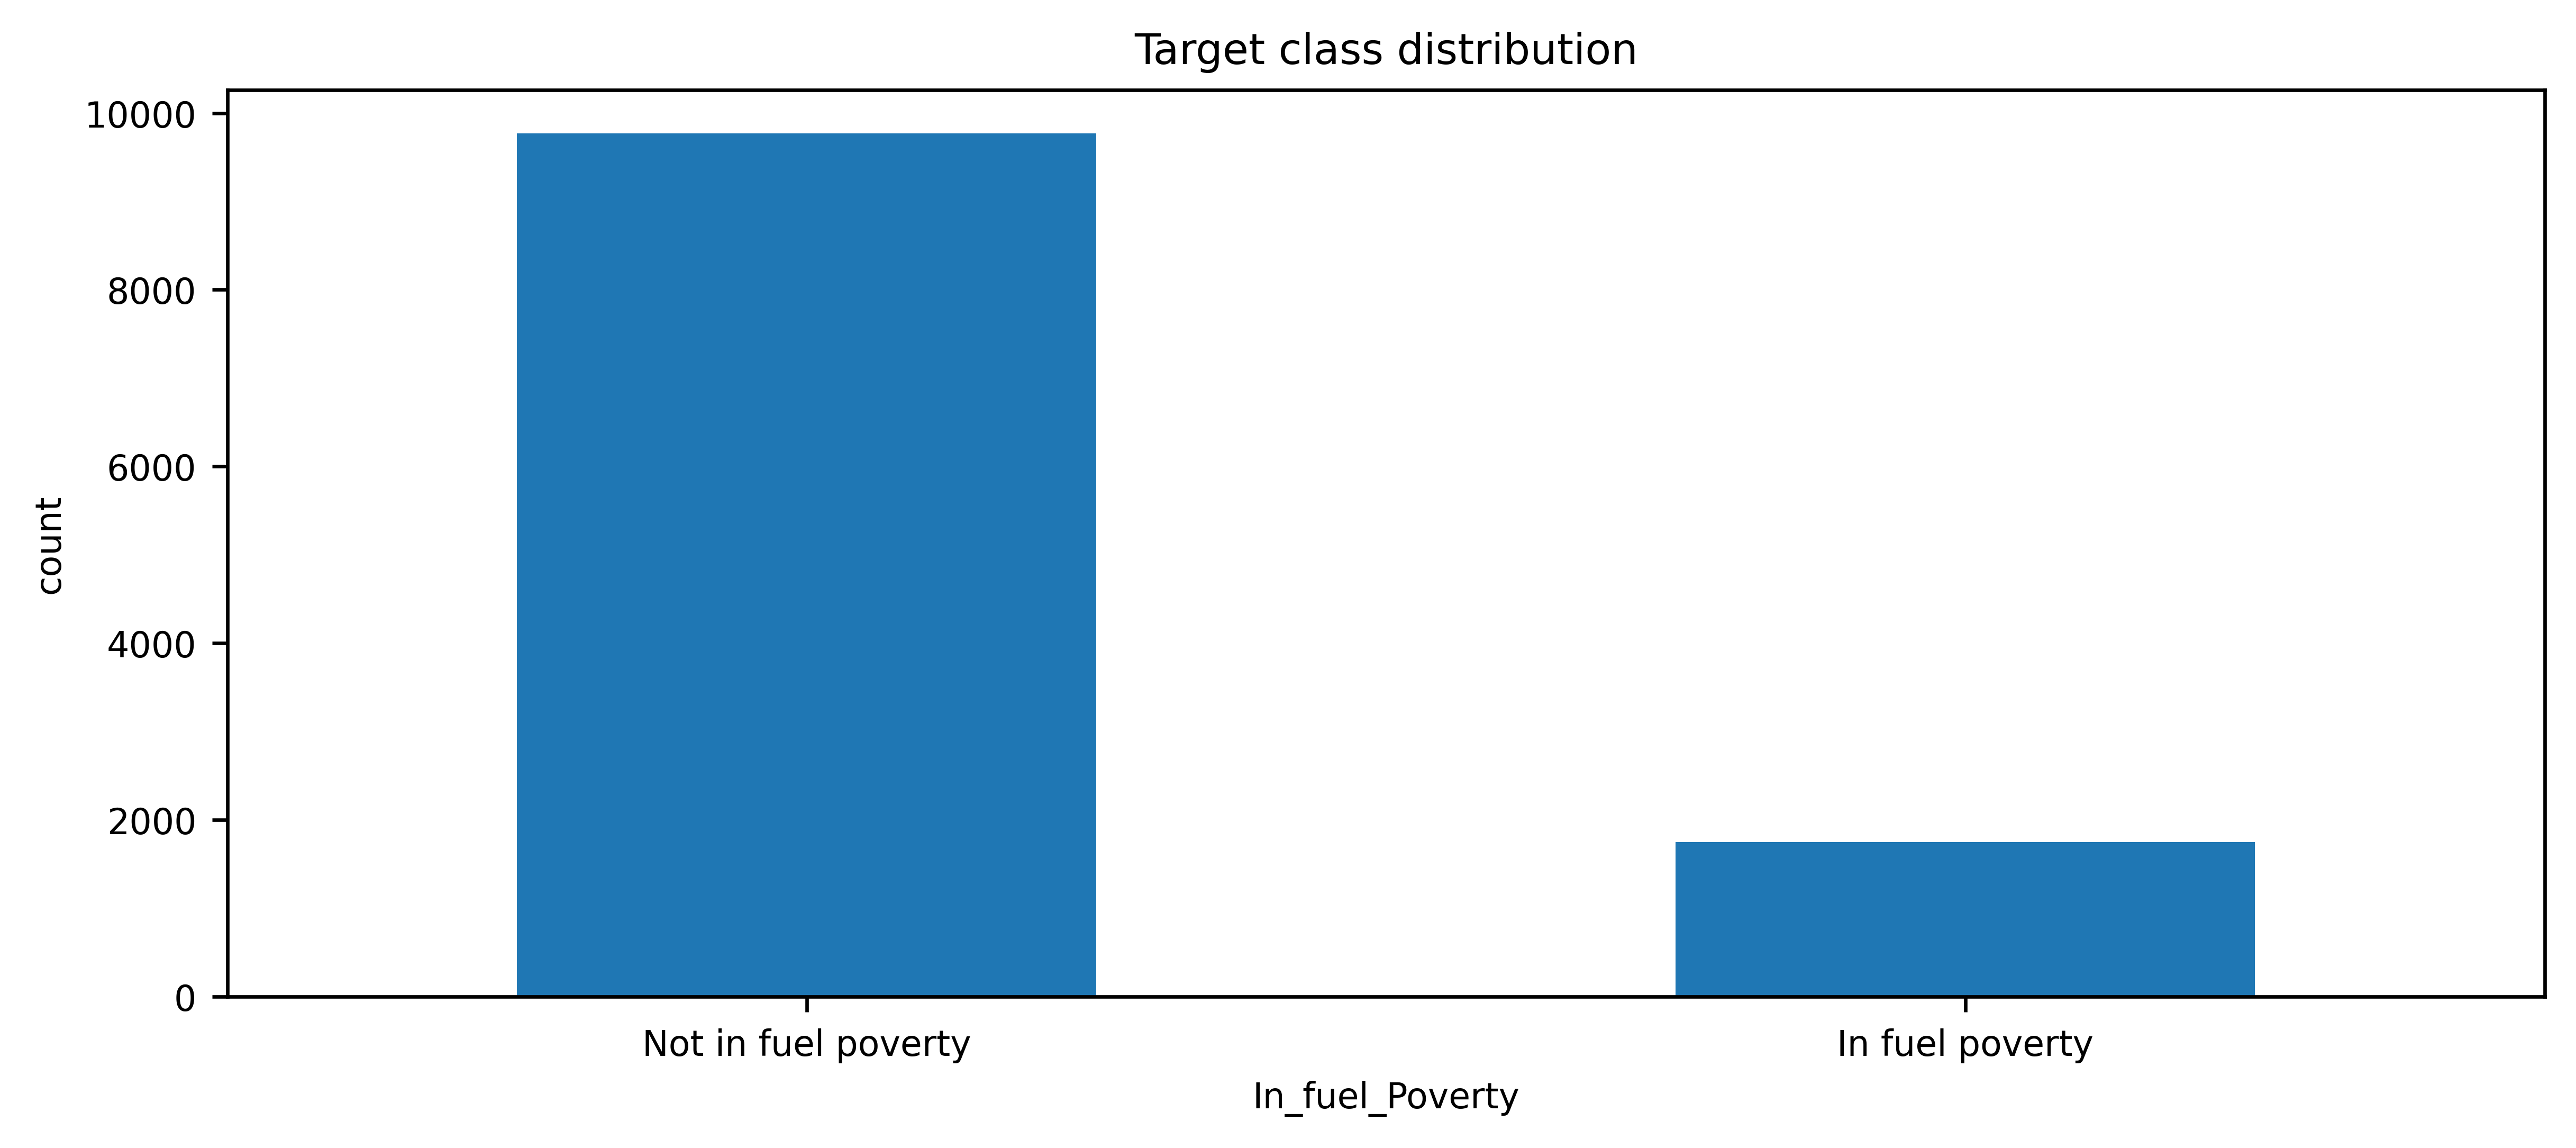

In [14]:
print(df["In_fuel_Poverty"].value_counts(dropna=False))
print("Fuel poverty share:", df["In_fuel_Poverty"].mean())

for col in ["Region", "Tenure", "DWtype", "Head_Working_Status", "Head_Ethnic_Origin", "EPC"]:
    if col in df.columns:

        counts = df[col].value_counts(dropna=False)
        plt.figure()
        counts.plot(kind="bar")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.xticks(rotation = 45)
        plt.title(f"Distribution of {col}")
        plt.show()

# Numerical summaries
for col in ["hh_income", "fuel_costs", "Under_occupied", "Age_of_youngest", "Age_of_oldest"]:
    if col in df.columns:
        print(f"Summary statistics for {col}")
        print(pd.to_numeric(df[col], errors='coerce').describe())

# Class balance visualization
plt.figure()
df["In_fuel_Poverty"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["Not in fuel poverty", "In fuel poverty"], rotation=0)
plt.ylabel("count")
plt.title("Target class distribution")
plt.show()


## Define the prediction problem

We now define the feature set and split the data into training and test subsets.


In [15]:
# list of features
feature_list = [
    "hh_income",
    "fuel_costs",
    "Under_occupied",
    "Region",
    "Tenure",
    "Head_Working_Status",
    "Head_Ethnic_Origin",
    "Age_of_youngest",
    "Age_of_oldest",
]

# keep only features that exist in the loaded file
feature_list = [c for c in feature_list if c in df.columns]

target_variable = "In_fuel_Poverty"
X = df[feature_list].copy()
Y = df[target_variable].copy()

categorical_features = [c for c in feature_list if X[c].dtype == 'object']
numerical_features = [c for c in feature_list if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

train_X, test_X, train_Y, test_Y = train_test_split(X,Y,test_size=0.30, random_state=random_state, stratify=Y,)

print("Train class balance")
print(train_Y.value_counts(normalize=True))
print("Test class balance")
print(test_Y.value_counts(normalize=True))


Categorical features: ['Region', 'Tenure', 'Head_Working_Status', 'Head_Ethnic_Origin']
Numerical features: ['hh_income', 'fuel_costs', 'Under_occupied', 'Age_of_youngest', 'Age_of_oldest']
Train class balance
In_fuel_Poverty
0    0.848214
1    0.151786
Name: proportion, dtype: float64
Test class balance
In_fuel_Poverty
0    0.84838
1    0.15162
Name: proportion, dtype: float64


## Fit classification models

We create a preprocessing pipeline with: 
- median imputation for numerical variables,
- most-frequent imputation for categorical variables,
- one-hot encoding for categorical variables.

We then compare four classifiers:
1. Logistic Regression
2. Extra Trees
3. Gradient Boosting

We evaluate classifiers using the confusion matrix and estimating accuracy, recall, precision, and Area Under Curve (AUC), which are standard metrics for binary classification problems. For more information, see [Google's ML crash course](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall?_gl=1*pdua9p*_up*MQ..*_ga*MTIzOTk2MzMyNi4xNzczNDM4NDI2*_ga_SM8HXJ53K2*czE3NzM0Mzg0MjYkbzEkZzAkdDE3NzM0Mzg0MjYkajYwJGwwJGgw).


Logistic regression
Confusion matrix (rows=true [0,1], cols=pred [0,1]):
 [[2318  614]
 [  94  430]]
Accuracy=0.795  Precision=0.412  Recall=0.821  F1=0.548  AUC=0.886
McFadden pseudo-R²=-0.025


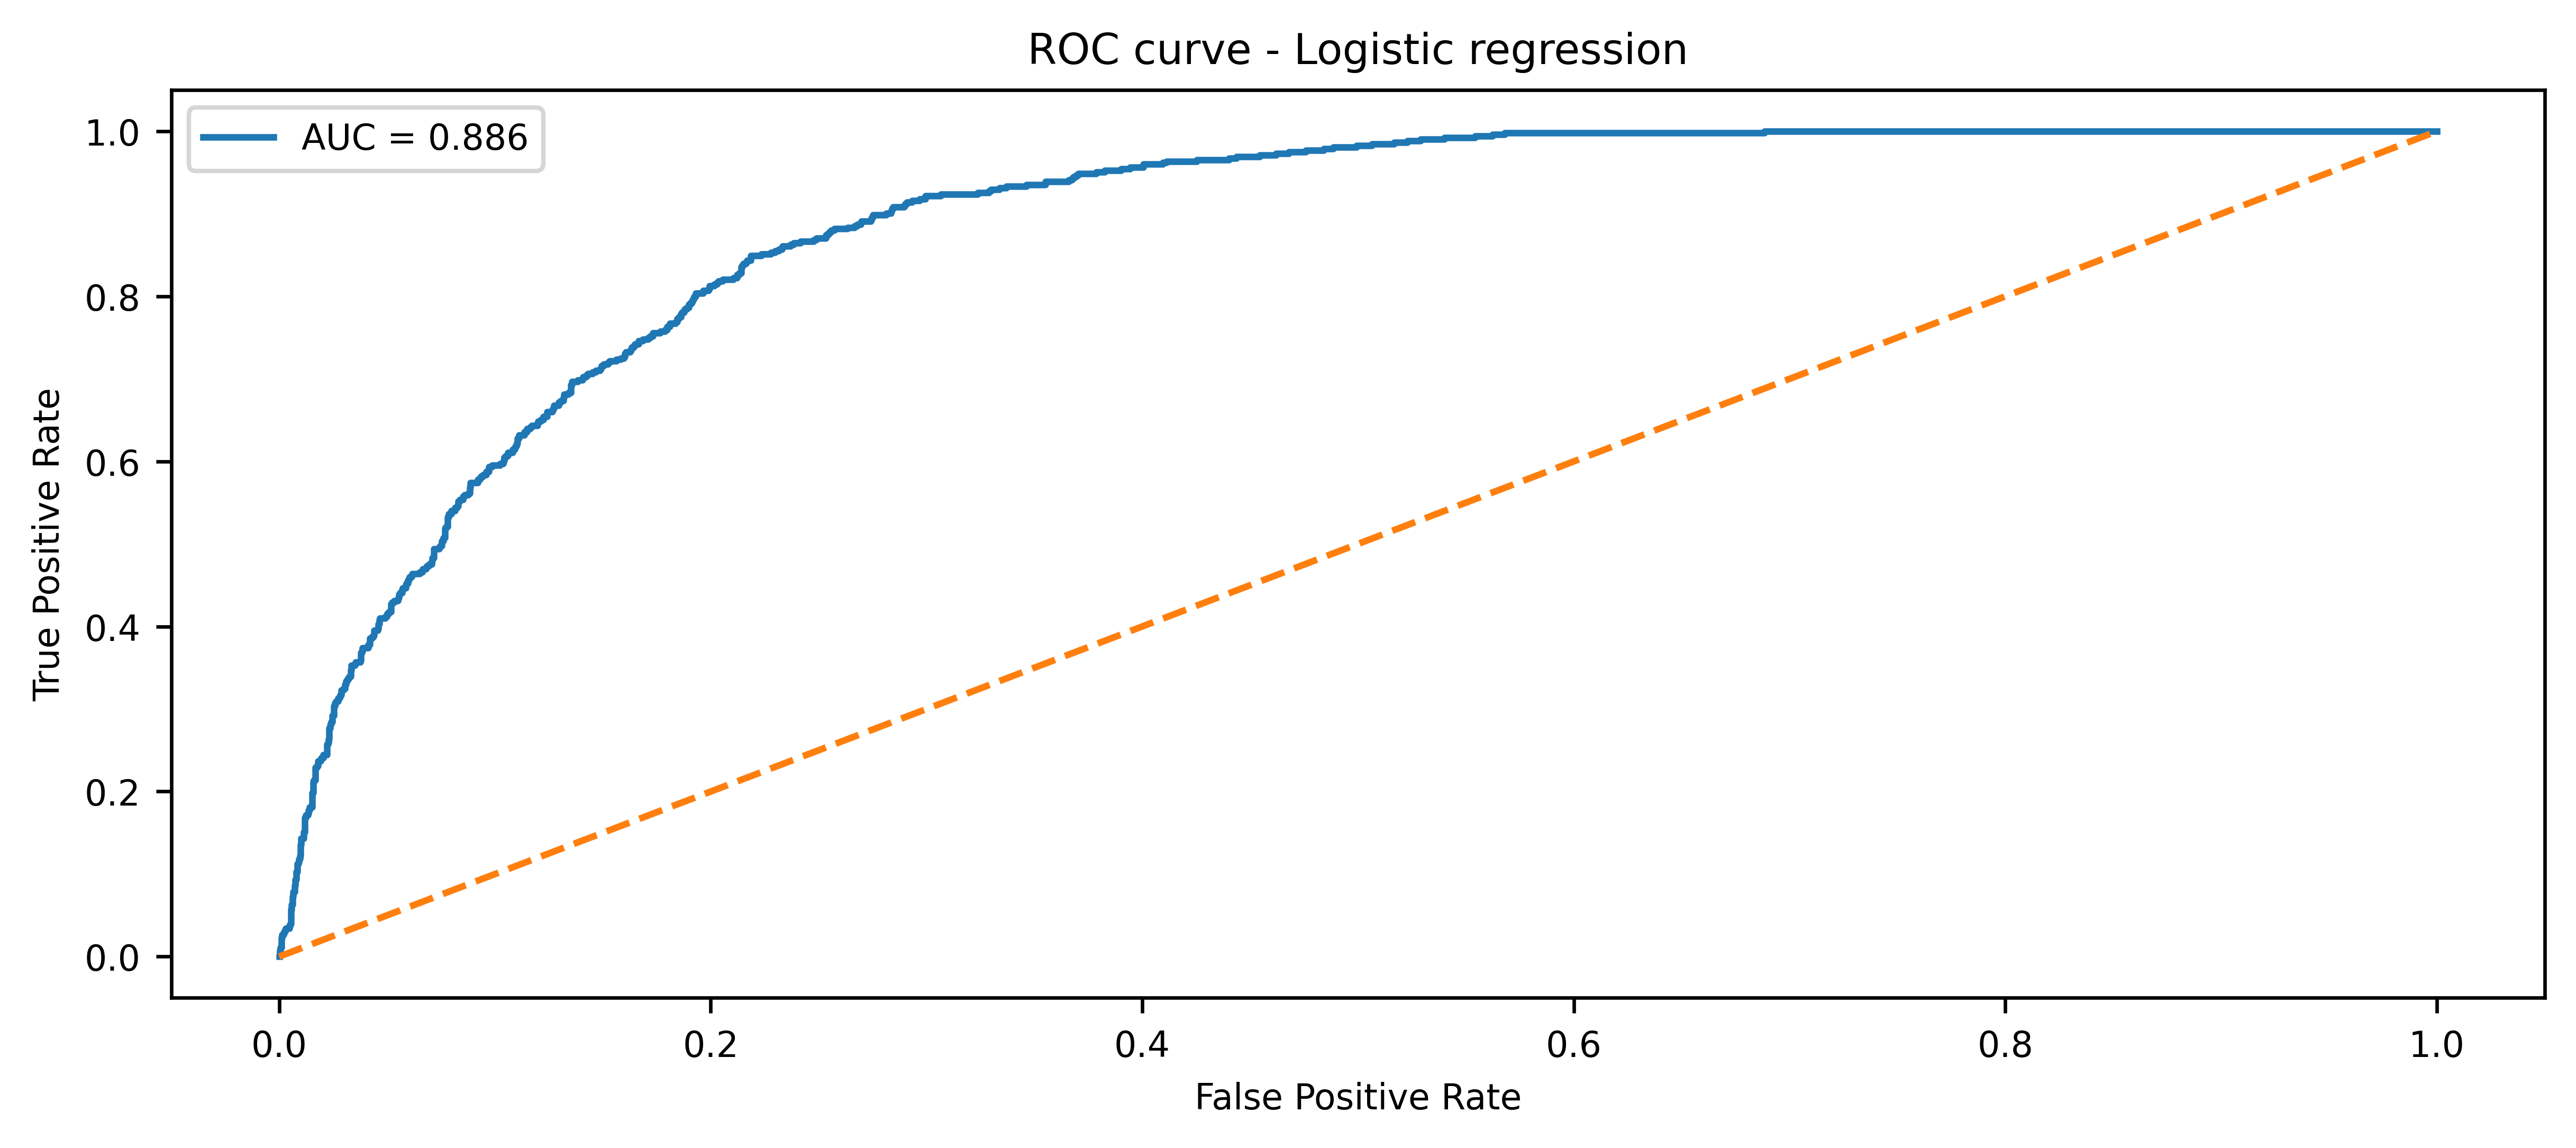


Extra Trees
Confusion matrix (rows=true [0,1], cols=pred [0,1]):
 [[2578  354]
 [ 197  327]]
Accuracy=0.841  Precision=0.480  Recall=0.624  F1=0.543  AUC=0.862
McFadden pseudo-R²=0.109


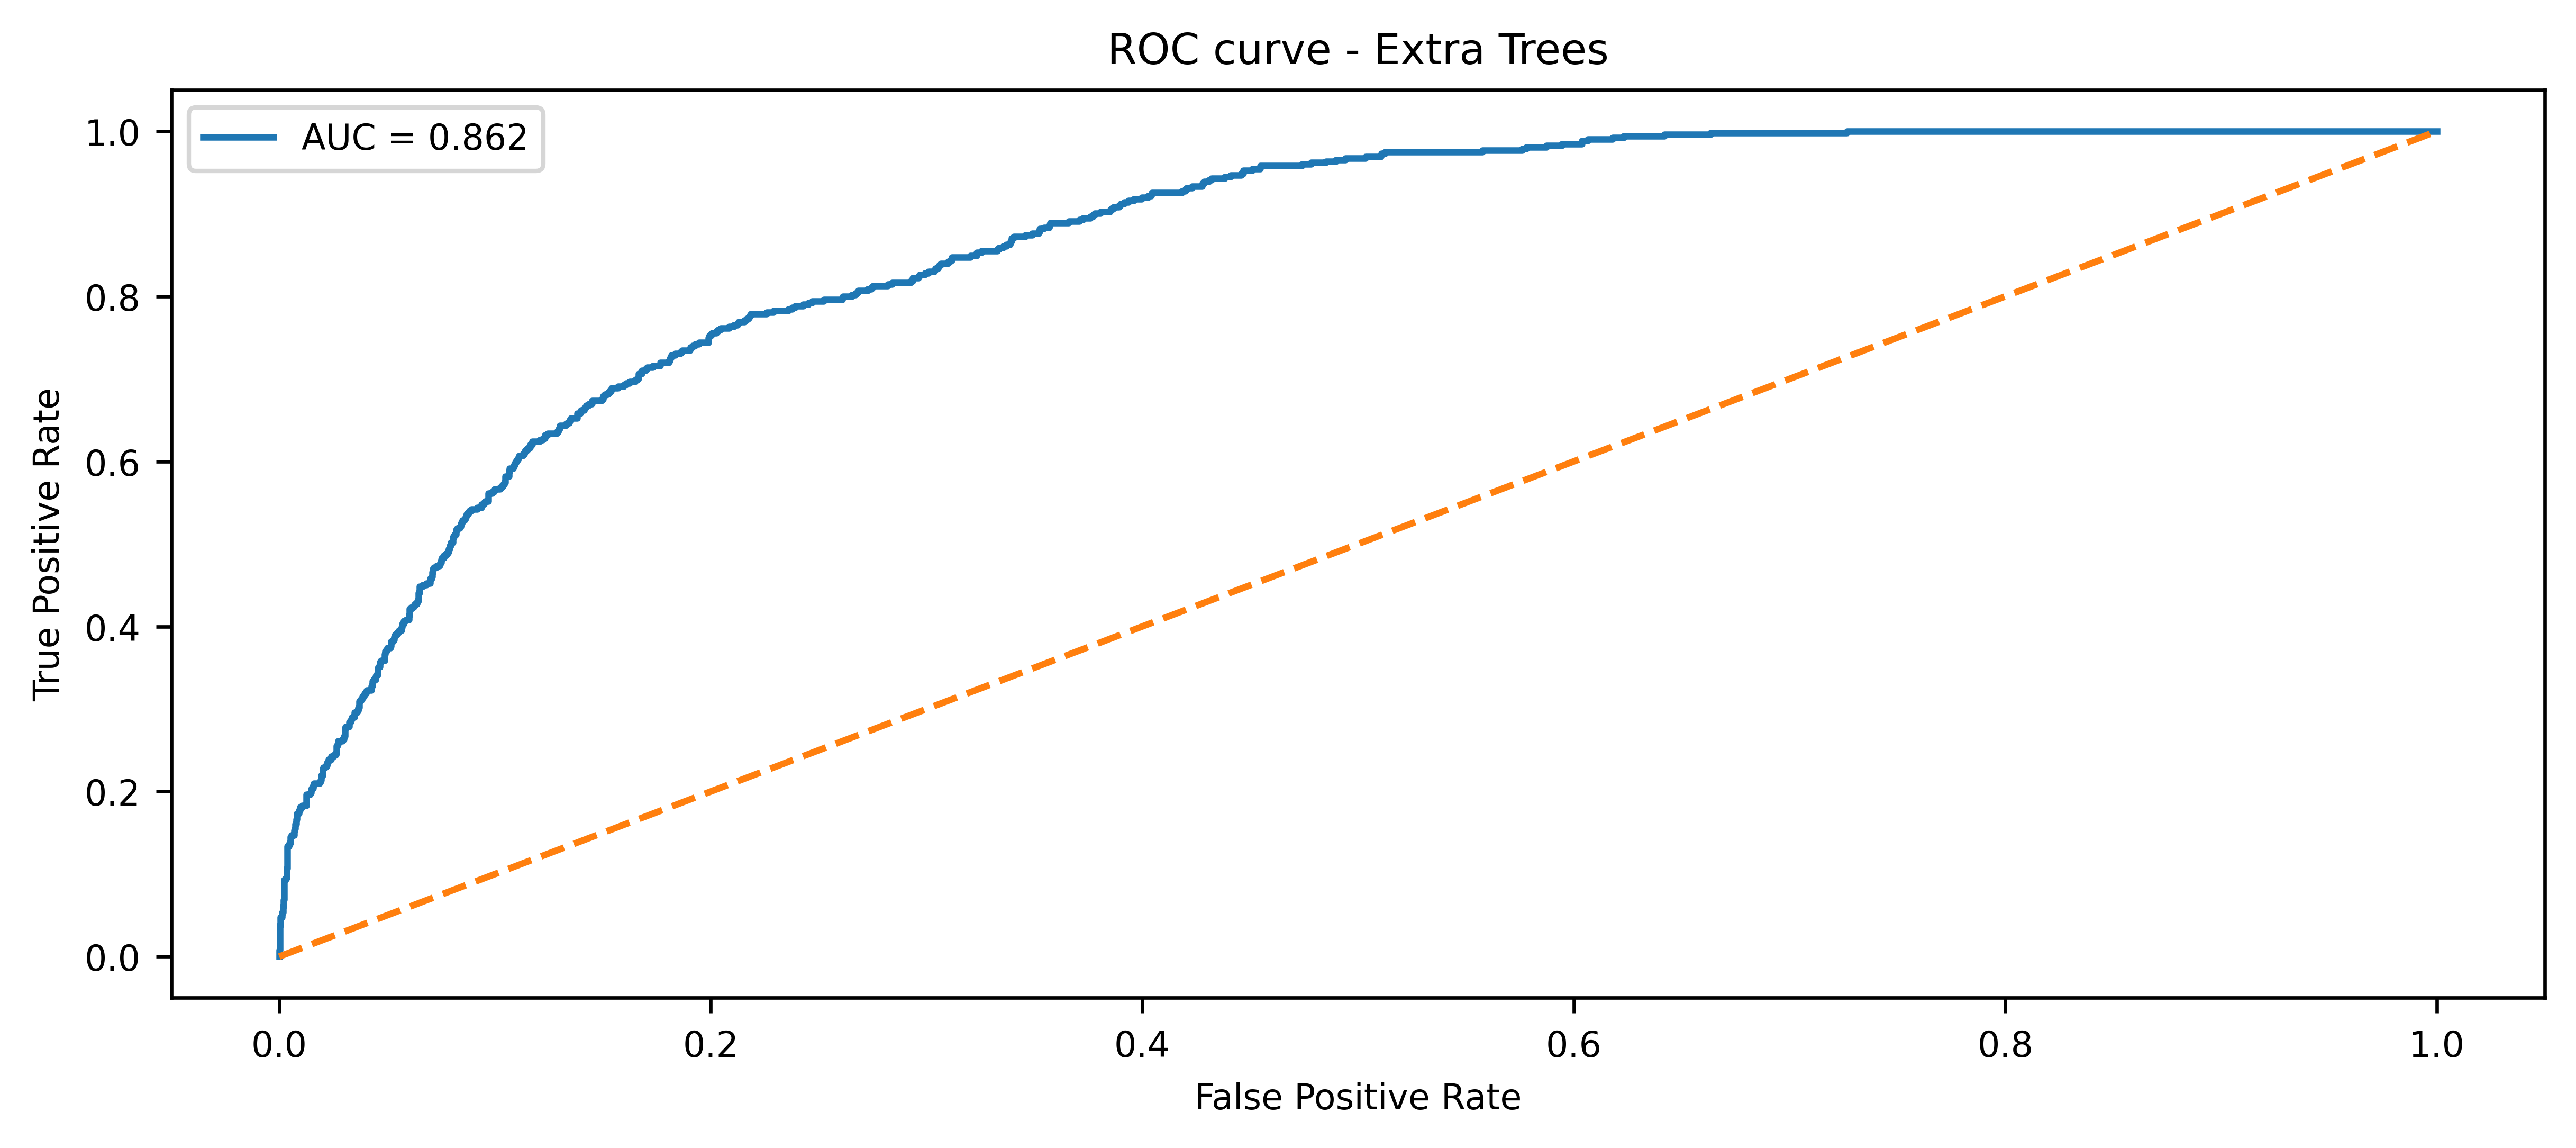


Gradient Boosting
Confusion matrix (rows=true [0,1], cols=pred [0,1]):
 [[2805  127]
 [ 272  252]]
Accuracy=0.885  Precision=0.665  Recall=0.481  F1=0.558  AUC=0.908
McFadden pseudo-R²=0.387


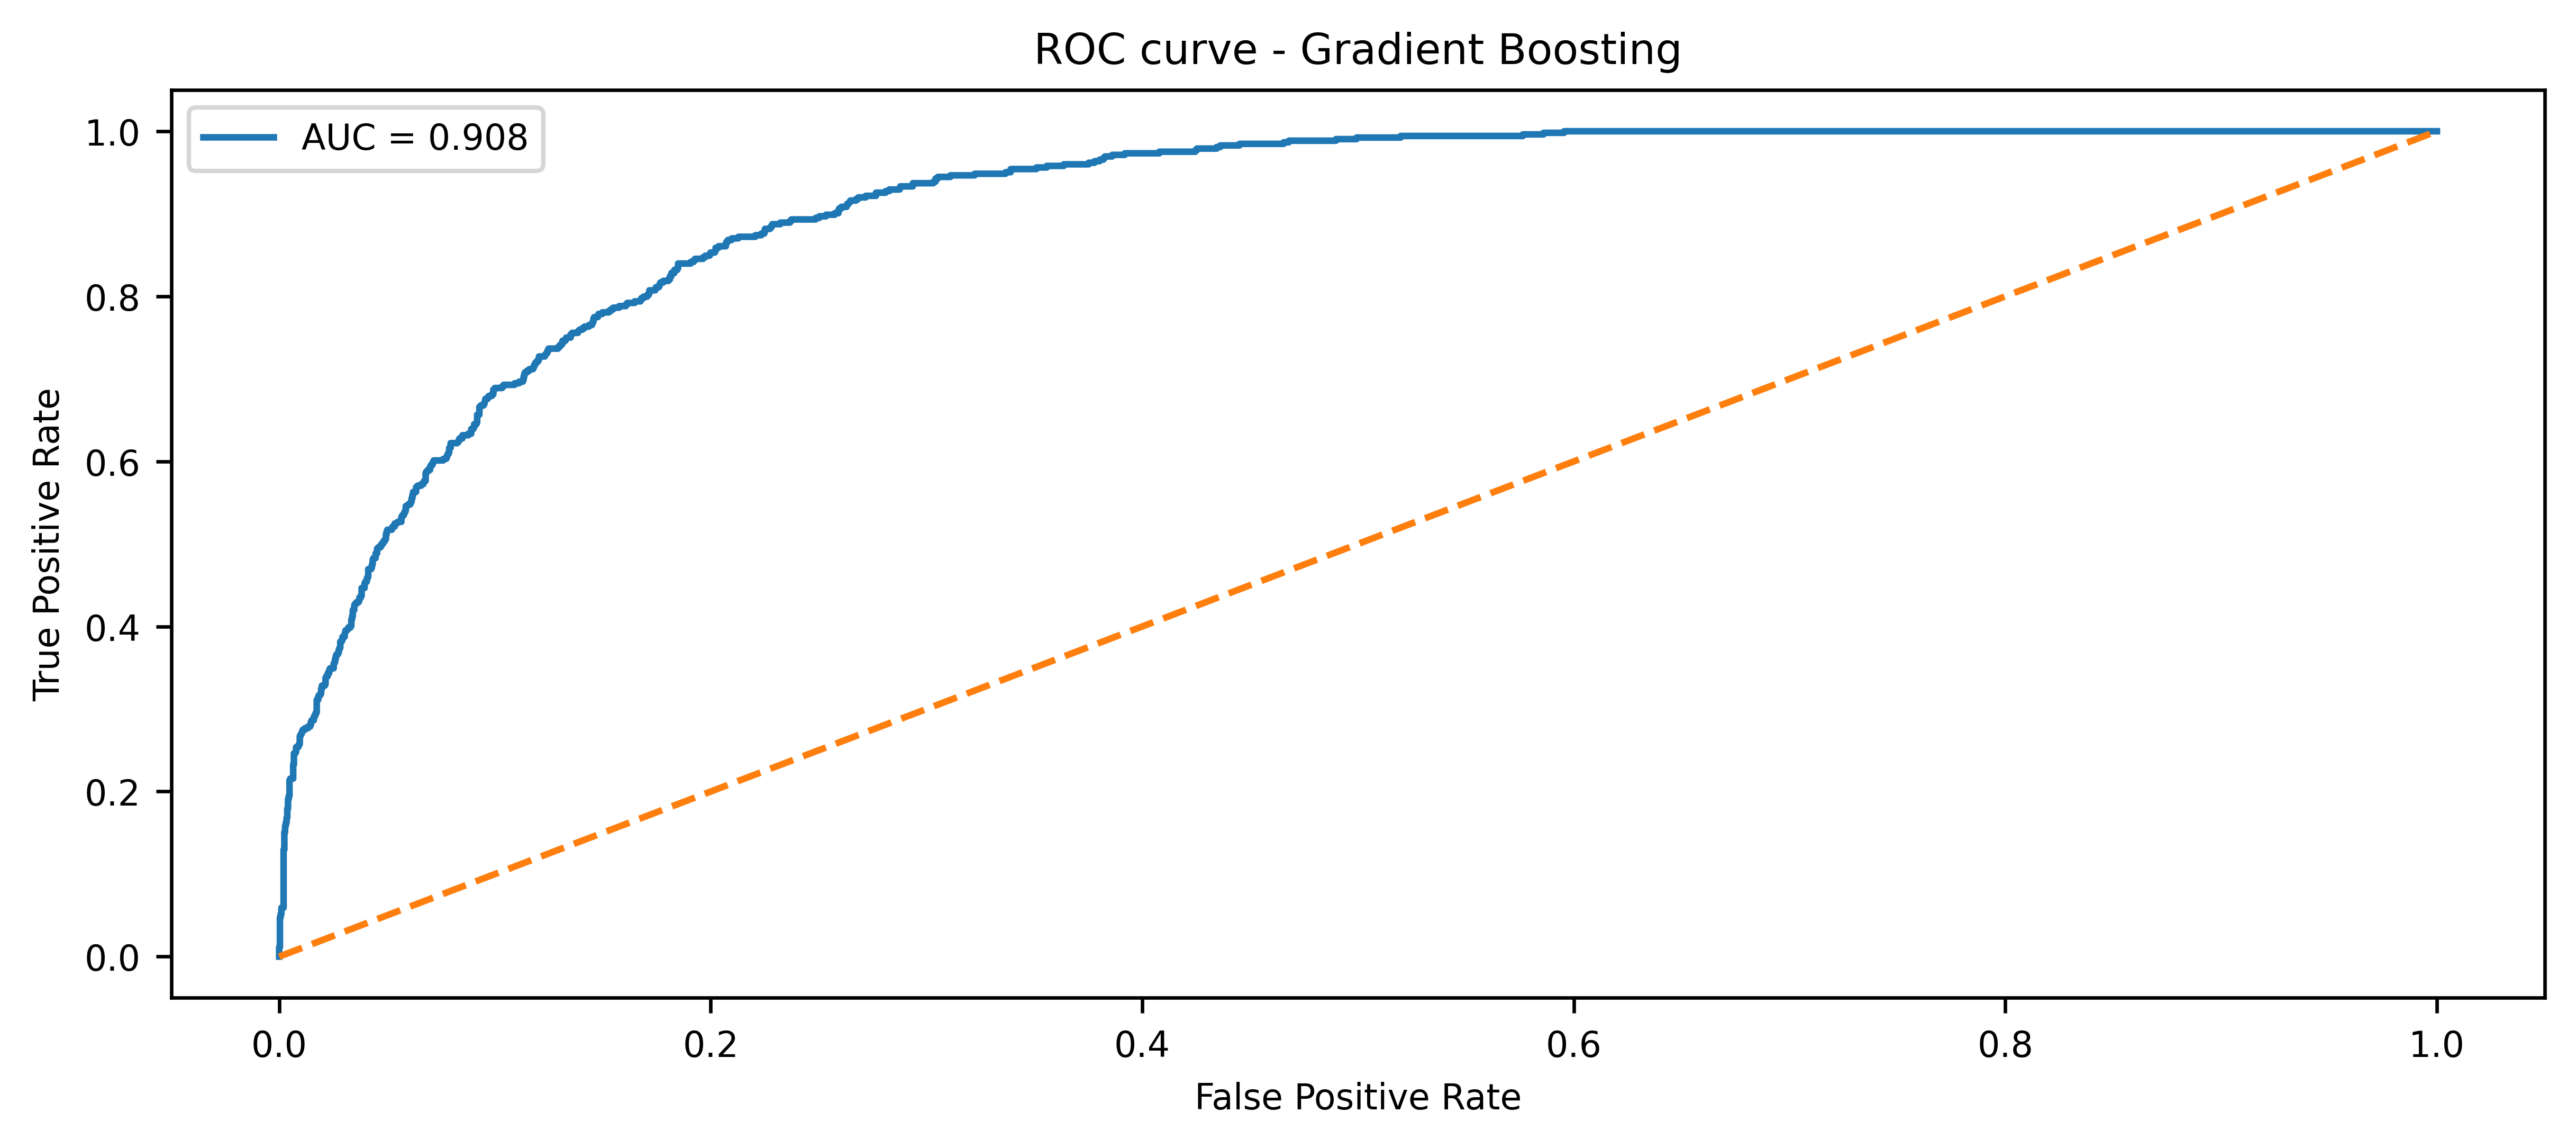

In [16]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),])

models = {
    "Logistic regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
        class_weight="balanced",),
    "Gradient Boosting": GradientBoostingClassifier(random_state=random_state),}

results = {}
fitted_models = {}

for model_name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])
    clf.fit(train_X, train_Y)
    proba = clf.predict_proba(test_X)[:, 1]
    results[model_name] = evaluate_binary_classifier(
        test_Y.values,
        proba,
        threshold=0.5,
        title_prefix=model_name,
        plot_roc=True,
    )
    fitted_models[model_name] = clf


In [17]:
# Compare models in a summary table
results_df = pd.DataFrame(results).T.sort_values("auc", ascending=False)
display(results_df)


,accuracy,precision,recall,f1,auc,mcfadden_r2
Gradient Boosting,0.884549,0.664908,0.480916,0.558140,0.907824,0.387217
Logistic regression,0.795139,0.411877,0.820611,0.548469,0.886067,-0.025148
Extra Trees,0.840567,0.480176,0.624046,0.542739,0.861883,0.109475


## Feature importance and permutation importance

We now assess feature importance using the best-performing tree-based model based on test AUC. Two complementary importance views are reported:
- **Built-in feature importance** from the tree ensemble.
- **Permutation importance** evaluated on the hold-out test set.

Because the preprocessing uses one-hot encoding, the built-in importances are first aggregated back to the original feature names.


Selected model for interpretation: Gradient Boosting


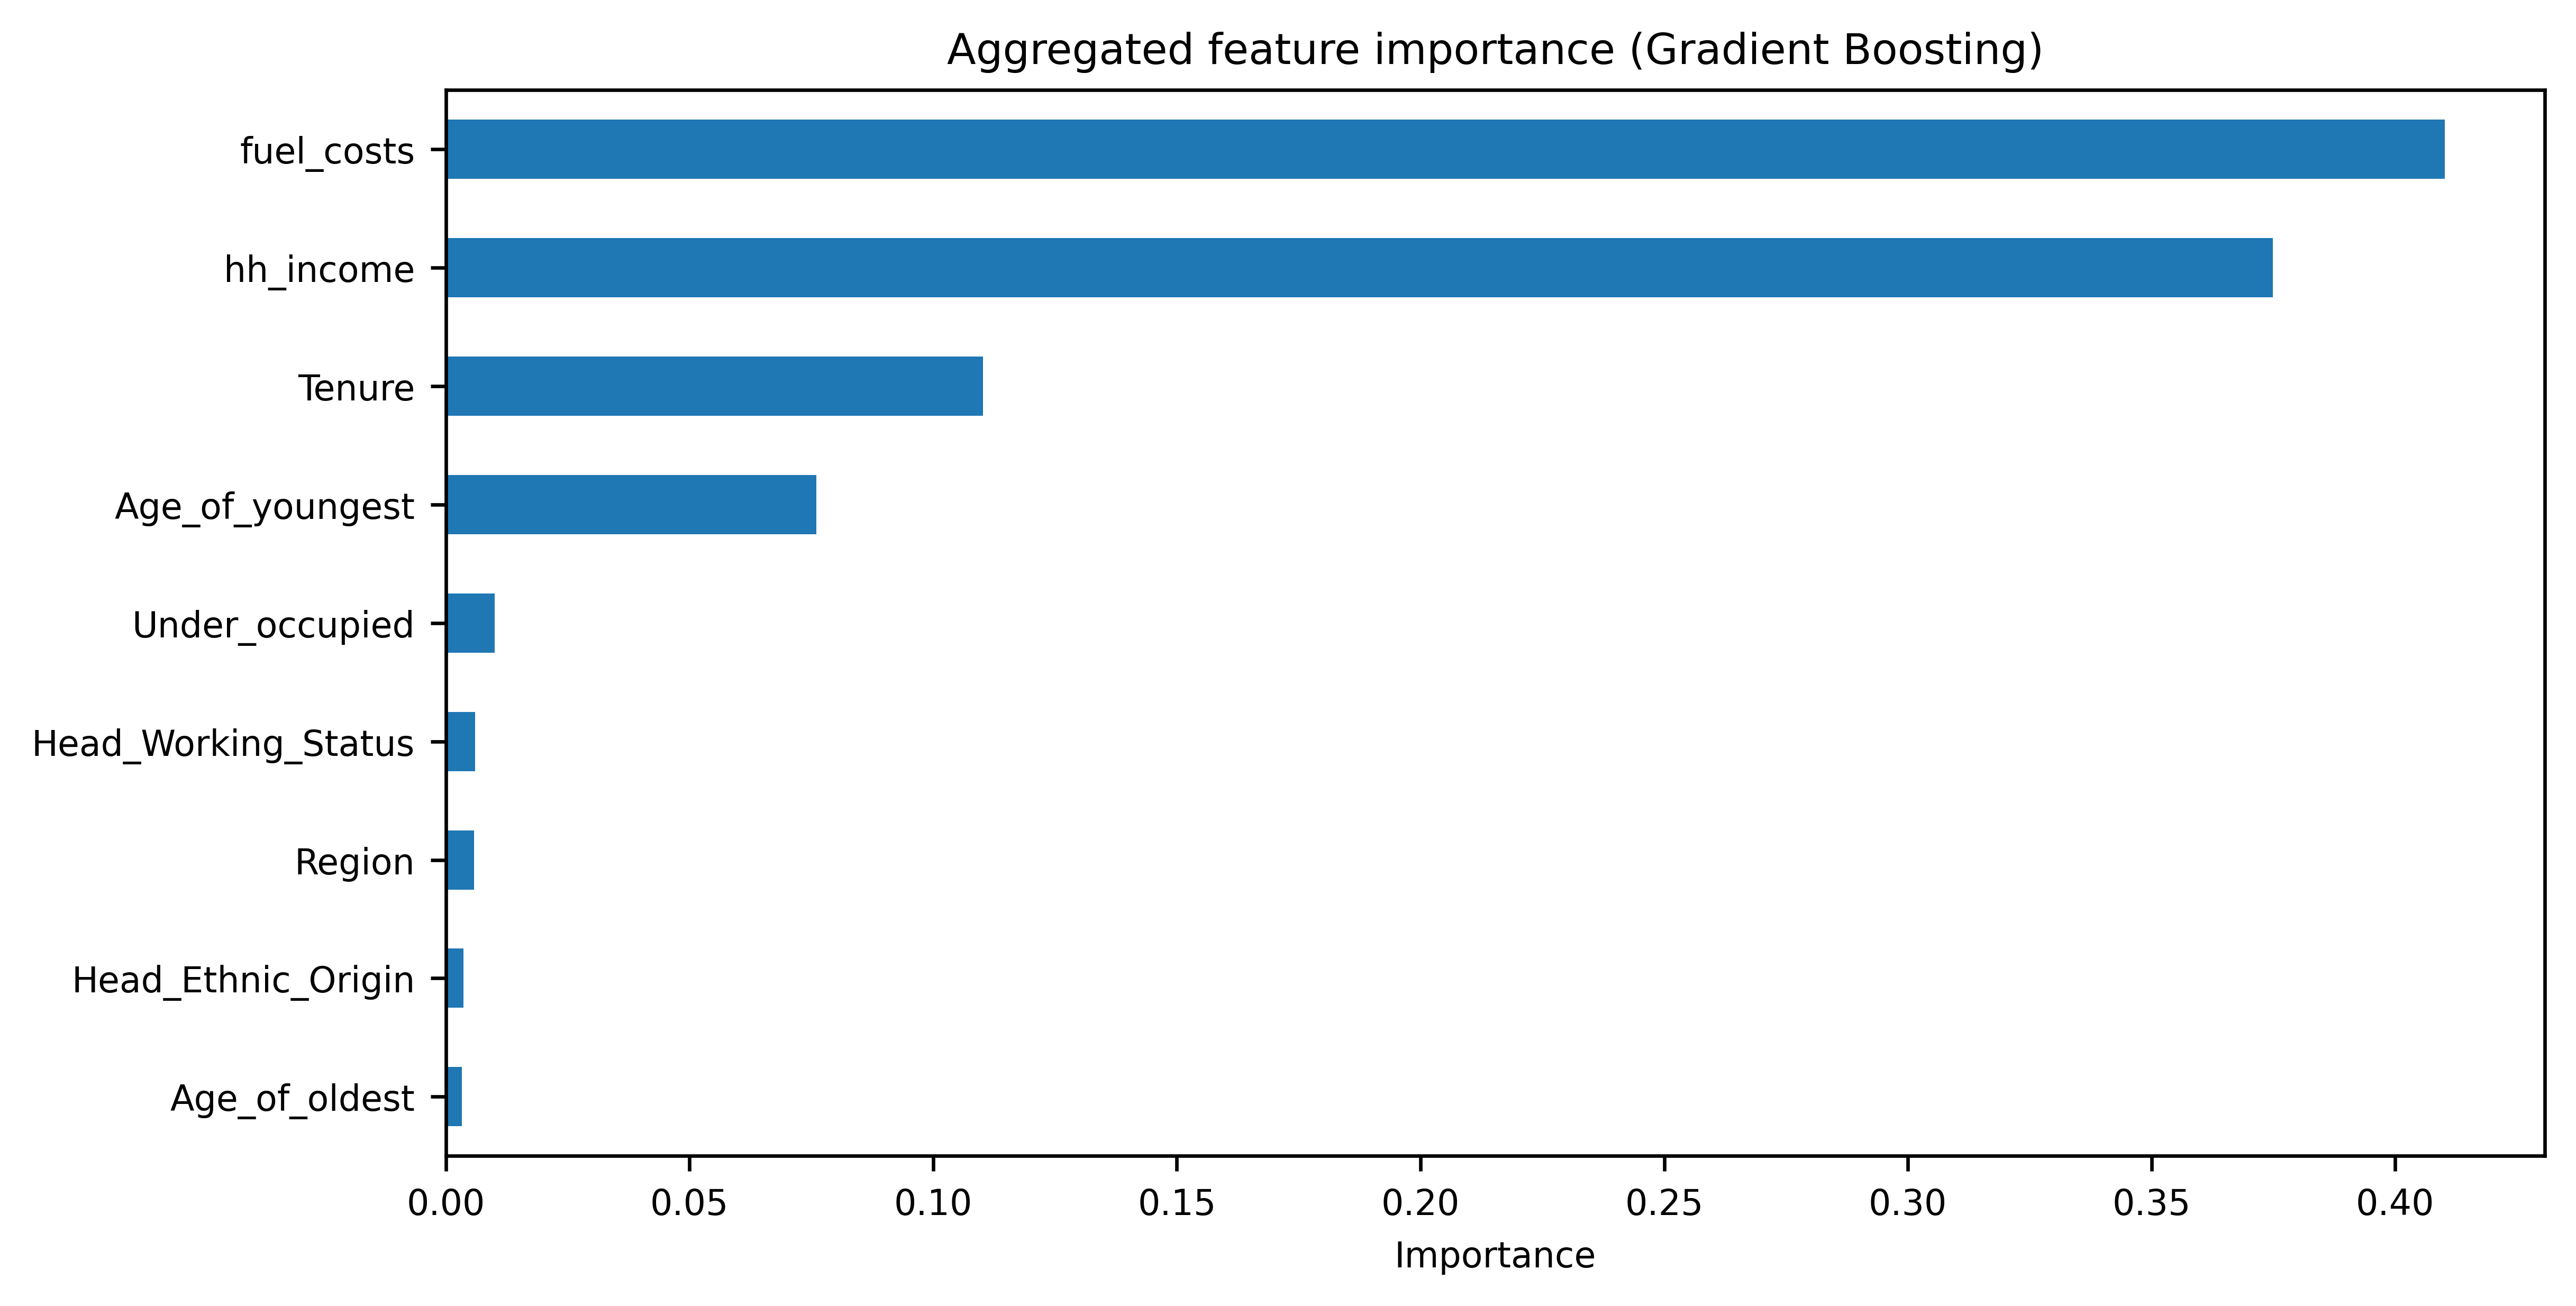

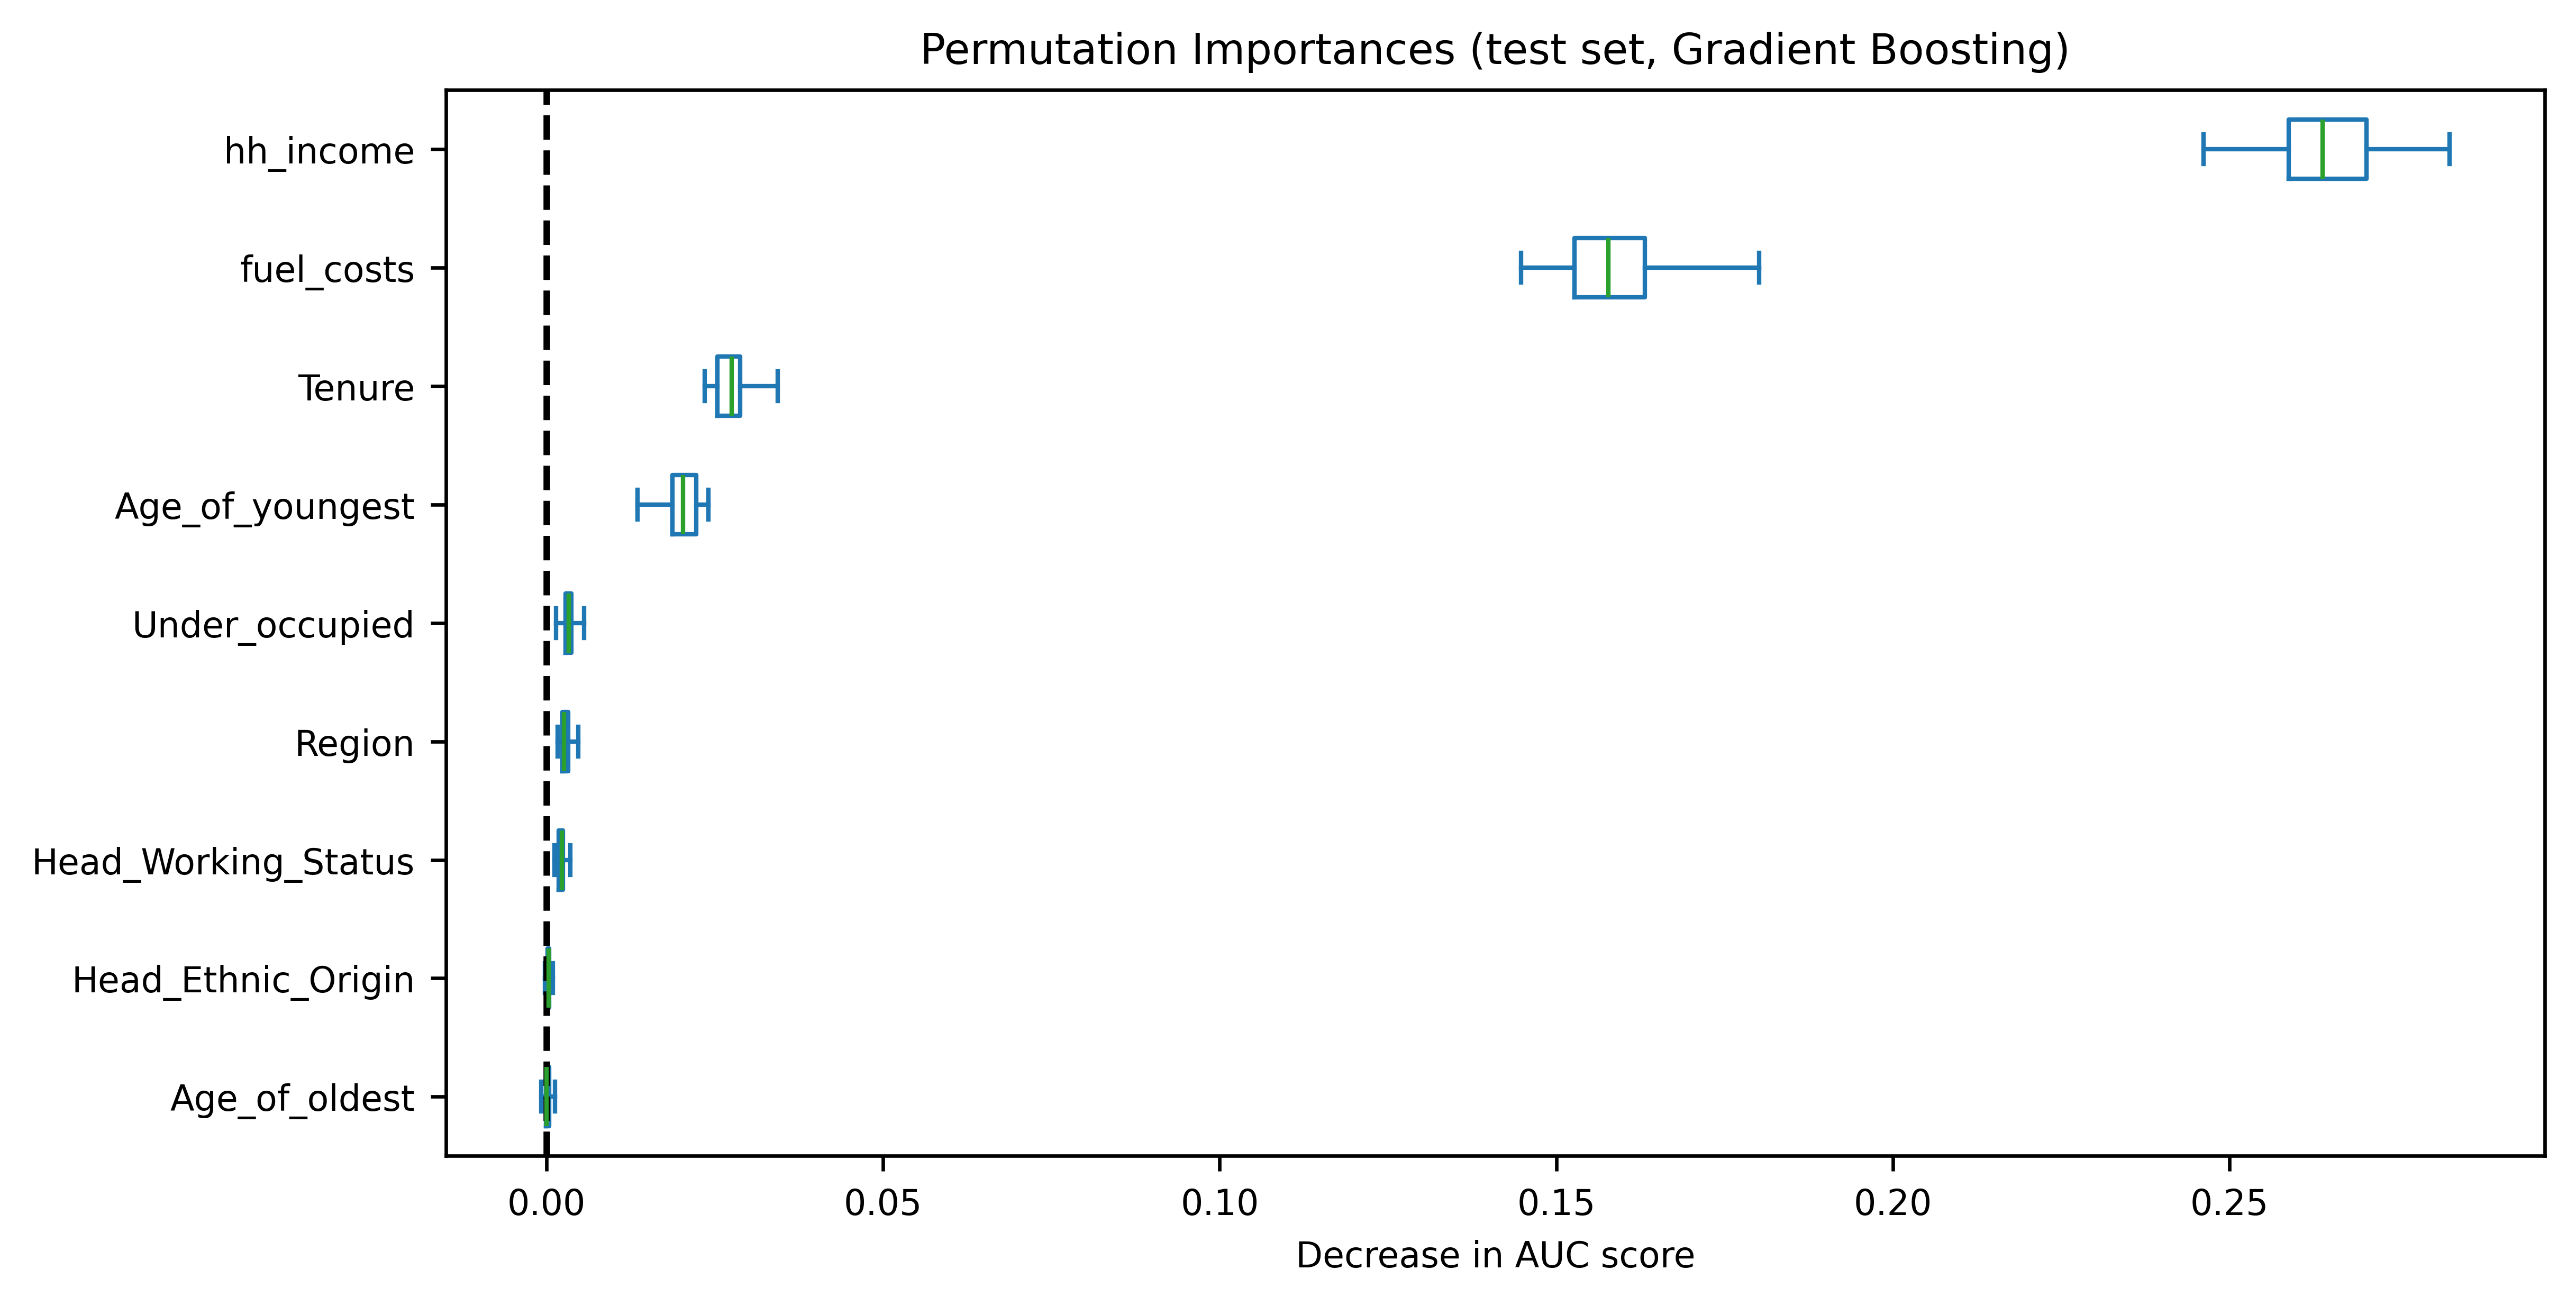

,mean_decrease_in_auc
hh_income,0.265299
fuel_costs,0.158435
Tenure,0.027468
Age_of_youngest,0.020245
Under_occupied,0.003341
Region,0.002828
Head_Working_Status,0.002197
Head_Ethnic_Origin,0.000318
Age_of_oldest,0.000119


In [18]:
# Choose the best tree-based model according to AUC
candidate_tree_models = [name for name in results_df.index if name in ["Random Forest", "Extra Trees", "Gradient Boosting"]]
best_tree_model_name = candidate_tree_models[0]
best_tree_model = fitted_models[best_tree_model_name]

print("Selected model for interpretation:", best_tree_model_name)

# Built-in feature importances (aggregated back to original features)
feature_names_after_preprocessing = best_tree_model.named_steps["preprocess"].get_feature_names_out()
raw_importances = best_tree_model.named_steps["model"].feature_importances_
aggregated_importances = aggregate_importances(
    feature_names_after_preprocessing,
    raw_importances,
    feature_list,
)

plt.figure(figsize=(8, 4))
aggregated_importances.plot(kind="barh")
plt.title(f"Aggregated feature importance ({best_tree_model_name})")
plt.xlabel("Importance")
plt.show()

# Permutation importance on original features
r = permutation_importance(
    best_tree_model,
    test_X,
    test_Y,
    n_repeats=30,
    random_state=random_state,
    scoring="roc_auc",
)

sorted_idx = r.importances_mean.argsort()
perm_importances = pd.DataFrame(
    r.importances[sorted_idx].T,
    columns=np.array(test_X.columns)[sorted_idx],
)

ax = perm_importances.plot.box(vert=False, whis=10, figsize=(8, 4))
ax.set_title(f"Permutation Importances (test set, {best_tree_model_name})")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in AUC score")
plt.show()

# Print mean permutation importance values
perm_mean = pd.Series(r.importances_mean, index=test_X.columns).sort_values(ascending=False)
display(perm_mean.to_frame("mean_decrease_in_auc"))


## Counterfactual interventions with a simple linear model

Suppose we decide to use **logistic regression** as the classifier. For a household with feature vector $x$, the fitted model predicts fuel poverty when the estimated probability exceeds 0.5. Equivalently, using the linear score

\begin{aligned}
s(x) = w^\top z(x) + b,
\end{aligned}

where $z(x)$ is the preprocessed feature vector after imputation and one-hot encoding, the classifier predicts:
\begin{aligned}
\hat y(x)=
\begin{cases}
1, & s(x)\ge 0 \\
0, & s(x)<0
\end{cases}
\end{aligned}
for the default threshold of 0.5.

For a household currently classified as **in fuel poverty** $(\hat y=1)$, we want the **smallest intervention** that changes the prediction to **not in fuel poverty**. A simple and transparent formulation is:

\begin{aligned}
\min_{\Delta x} \quad & \sum_{j \in \mathcal{A}} c_j |\Delta x_j| \\
\text{s.t.} \quad & w^\top z(x+\Delta x) + b \le -\varepsilon \\
& l_j \le x_j + \Delta x_j \le u_j, \quad j \in \mathcal{A} \\
& \Delta x_j = 0, \quad j \notin \mathcal{A}
\end{aligned}

where:

- $\mathcal{A}$ is the set of **actionable** features (can be changed),
- $c_j$ are feature-specific intervention costs,
- $[l_j, u_j]$ are feasible bounds,
- $\varepsilon > 0$ is a small safety margin.

Because logistic regression is linear in the transformed features, this counterfactual problem can be solved as a **small linear program** once we keep categorical variables fixed and only allow changes in selected numerical features.

In the example below, we make a deliberately simple policy choice:

- **actionable:** `hh_income` (can only increase), `fuel_costs` (can only decrease),
- **fixed / immutable:** age variables, occupancy indicator, and all categorical variables.

You can modify these assumptions later to reflect a more realistic intervention model.


In [27]:
# ------------------------------------------------------------
# Select the simple linear model: logistic regression
# ------------------------------------------------------------
linear_model_name = "Logistic regression"
linear_clf = fitted_models[linear_model_name]

# Find a test-set observation currently predicted as in fuel poverty
proba = linear_clf.predict_proba(test_X)[:, 1]
test_pred_linear = linear_clf.predict(test_X)
positive_idx = np.where(test_pred_linear == 1)[0]

if len(positive_idx) == 0:
    raise ValueError("No test observation is currently classified as fuel poor by the logistic model.")

# Select test-set observation
idx = 0
obs_idx = int(positive_idx[idx])
x0 = test_X.iloc[[obs_idx]].copy()

print(f"Selected test observation index: {x0.index[0]}")
display(x0)

print("Original predicted probability of fuel poverty:",
      float(linear_clf.predict_proba(x0)[0, 1]))
print("Original predicted class:", int(linear_clf.predict(x0)[0]))


# Transform the selected point
z0 = preprocessor.transform(x0)
if hasattr(z0, "toarray"):
    z0 = z0.toarray()
z0 = np.asarray(z0).ravel()
print('Transformed feature')
display(z0.round(3))

Selected test observation index: 4373


,hh_income,fuel_costs,Under_occupied,Region,Tenure,Head_Working_Status,Head_Ethnic_Origin,Age_of_youngest,Age_of_oldest
4373,13647,785.35,0,South East,housing association,inactive,white,2,2


Original predicted probability of fuel poverty: 0.6002387388605258
Original predicted class: 1
Transformed feature


array([1.3647e+04, 7.8535e+02, 0.0000e+00, 2.0000e+00, 2.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00])

In [34]:
import cvxpy as cp

# Logistic regression parameters in transformed space
w = linear_clf.named_steps["model"].coef_.ravel()
b = linear_clf.named_steps["model"].intercept_[0]

# # Feature names after preprocessing
print(feature_names_after_preprocessing)
# Actionable transformed features and their costs
# Adjust these names to match your preprocessing output exactly
actionable_costs = {
    "num__hh_income": 1.0,     # can increase
    "num__fuel_costs": 1.0,    # can decrease
}

# Small margin to ensure the counterfactual is on the desired side
epsilon = 1e-3

# Build optimization variables
delta = cp.Variable(len(w))

constraints = []

# Non-actionable features remain fixed
actionable_idx = [i for i, f in enumerate(feature_names_after_preprocessing) if f in actionable_costs]
non_actionable_idx = [i for i in range(len(feature_names_after_preprocessing)) if i not in actionable_idx]

for i in non_actionable_idx:
    constraints += [delta[i] == 0]

# Direction constraints
# income can only increase
if "num__hh_income" in feature_names_after_preprocessing:
    i_income = np.where(feature_names_after_preprocessing == "num__hh_income")[0][0]
    constraints += [delta[i_income] >= 0]

# fuel costs can only decrease
if "num__fuel_costs" in feature_names_after_preprocessing:
    i_fuel = np.where(feature_names_after_preprocessing == "num__fuel_costs")[0][0]
    constraints += [delta[i_fuel] <= 0]

# Classification flip constraint:
# move to the "not fuel poor" side of the linear boundary
constraints += [w @ (z0 + delta) + b <= -epsilon]

# Weighted L1 objective
objective = cp.Minimize(
    cp.sum([
        actionable_costs[feature_names_after_preprocessing[i]] * cp.abs(delta[i])
        for i in actionable_idx
    ])
)

problem = cp.Problem(objective, constraints)
problem.solve(verbose = False)

print("Optimization status:", problem.status)
print("Optimal objective value:", problem.value)

['num__hh_income' 'num__fuel_costs' 'num__Under_occupied'
 'num__Age_of_youngest' 'num__Age_of_oldest' 'cat__Region_East'
 'cat__Region_East Midlands' 'cat__Region_London' 'cat__Region_North East'
 'cat__Region_North West' 'cat__Region_South East'
 'cat__Region_South West' 'cat__Region_West Midlands'
 'cat__Region_Yorkshire and the Humber' 'cat__Tenure_housing association'
 'cat__Tenure_local authority' 'cat__Tenure_owner occupied'
 'cat__Tenure_private rented' 'cat__Head_Working_Status_inactive'
 'cat__Head_Working_Status_unemployed' 'cat__Head_Working_Status_working'
 'cat__Head_Ethnic_Origin_ethnic minority' 'cat__Head_Ethnic_Origin_white']
Optimization status: optimal
Optimal objective value: 111.57454813832064


In [35]:
# Construct counterfactual in transformed space
delta_star = delta.value
x_cf_trans = z0 + delta_star

# Show nonzero interventions
cf_changes = pd.DataFrame({
    "feature": feature_names_after_preprocessing,
    "original_transformed": z0,
    "delta": delta_star,
    "counterfactual_transformed": x_cf_trans
})

cf_changes = cf_changes[np.abs(cf_changes["delta"]) > 1e-6].sort_values("delta", key=np.abs, ascending=False)
cf_changes

# Verify score flip in transformed space
score_before = w @ z0 + b
score_after = w @ x_cf_trans + b

print("Score before:", score_before)
print("Score after :", score_after)

print('Minimal intervention to get out of fuel poverty (linear model)')
for i in range(len(delta_star)):
    temp_d = delta_star[i].round(3)
    if temp_d == 0:
        continue
    
    print(f'Feature:{feature_names_after_preprocessing[i]}')
    print(f'Delta:{delta_star.round(3)[i]}')

# print("Target satisfied:", score_after <= -epsilon)

Score before: 0.40645995240406224
Score after : -0.0009999973033138487
Minimal intervention to get out of fuel poverty (linear model)
Feature:num__fuel_costs
Delta:-111.575


### Interpretation

This section computes a **minimum-cost counterfactual intervention** for one observation, under a simple set of assumptions.

A few important remarks:

1. The result is only as meaningful as the **actionability assumptions**.  
   For example, increasing income is not the same type of intervention as reducing fuel costs through retrofit, tariff support, or improved efficiency.

2. The objective here is a **weighted \(L_1\)** distance, which tends to produce sparse interventions.  
   If you want smoother changes, you could switch to a weighted \(L_2\) objective.

3. With a **linear classifier**, this is relatively easy because the class-flip constraint is linear.  
   For tree ensembles or neural networks, the same idea usually requires a more complex optimization or a heuristic search method.

4. A natural extension is to include more realistic actionable variables such as EPC-related characteristics, heating technology, or insulation indicators, provided these are available and carefully encoded.
